#### Amazon Review Recommendation System


<a id='table-of-contents'></a>
**CONTENTS**
- [1. Environment Setup](#section-1-environment-setup)
- [2. Data Pipeline](#section-2-data-pipeline)
- [3. Helper Functions](#section-3-helper-functions)
- [4. MLP Two Tower - Baseline](#section-4-mlp-baseline)
- [5. LightGCN - Baseline](#section-5-lightgcn-baseline)
- [6. Other Ranking Models](#section-6-ranking-models)
  - [6.1 LightGCL](#section-6-lightgcl)
  - [6.2 GATv2](#section-6-gatv2)
  - [6.3 GraphSAGE](#section-6-graphsage)
  - [6.4 SVD Graph Fusion](#section-6-svd-graph-fusion)
- [7. Final Comparison](#section-7-final-comparison)
- [8. Model Behavior Analysis](#section-8-model-behavior-analysis)


<a id='section-1-environment-setup'></a>
##### 1. Environment Setup


In [1]:
import os
import random
import time
import warnings
from collections import defaultdict
from pathlib import Path
from typing import Dict, Optional

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import scipy.sparse as sp
from scipy.sparse.linalg import svds
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import DataLoader, Dataset
from IPython.display import display

from models.two_tower import TwoTowerMLP as MLPTwoTower
from models.lightgcn import LightGCN
from training.datasets import BPRDataset, build_user_positive_items
from training.two_tower_bpr import train_two_tower_bpr_epoch
from training.lightgcn_bpr import train_lightgcn_bpr_epoch, sample_bpr_batch

try:
    from torch_geometric.nn import GATv2Conv
    HAS_TORCH_GEOMETRIC = True
    GATV2_IMPORT_ERROR = None
except Exception as exc:
    HAS_TORCH_GEOMETRIC = False
    GATV2_IMPORT_ERROR = repr(exc)

warnings.filterwarnings('ignore')

SEED = 42

def set_global_seed(seed: int = 42) -> None:
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    if torch.cuda.is_available():
        torch.cuda.manual_seed_all(seed)
    torch.backends.cudnn.deterministic = True
    torch.backends.cudnn.benchmark = False

set_global_seed(SEED)
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
project_root = Path.cwd()
data_dir = project_root / 'data'
model_dir = project_root / 'model_pth'
results_dir = project_root / 'results'
config_dir = project_root / 'configs'
model_dir.mkdir(exist_ok=True)
results_dir.mkdir(exist_ok=True)

print(f'PyTorch version: {torch.__version__}')
print(f'CUDA available: {torch.cuda.is_available()}')
print(f'Using device: {device}')
print(f'Project root: {project_root}')


PyTorch version: 2.9.1+cu130
CUDA available: True
Using device: cuda
Project root: c:\Users\ZHIPE\Desktop\Georgia Tech\7643 Deep Learning\Final Project\Project


In [2]:
DEFAULT_CONFIG = {
    'dataset': {'name': 'Amazon Musical Instruments', 'ratings_path': 'data/ratings_Musical_Instruments.csv', 'k_core': 3},
    'protocol': {
        'rating_filter': 3.0,
        'test_ratio': 0.20,
        'val_ratio_within_train': 0.125,
        'top_k': 20,
        'relevance_threshold': 3.0,
        'epochs': 50,
        'patience': 5,
        'early_stop_metric': 'NDCG@20',
        'force_retrain': False,
    },
    'models': {
        'two_tower_bpr': {'embedding_dim': 64, 'hidden_dims': [128, 64], 'lr': 1e-3, 'batch_size': 1024, 'reg_weight': 1e-4},
        'lightgcn_bpr': {'embedding_dim': 64, 'n_layers': 3, 'lr': 1e-3, 'batch_size': 1024, 'reg_weight': 1e-4},
        'lightgcl': {'embedding_dim': 64, 'n_layers': 2, 'svd_rank': 5, 'dropout': 0.0, 'lr': 1e-3, 'batch_size': 2048, 'tau': 0.5, 'lam_cl': 0.2, 'lam_reg': 1e-7},
        'gatv2': {'embedding_dim': 64, 'n_layers': 2, 'n_heads': 4, 'dropout': 0.0, 'lr': 1e-3, 'batch_size': 1024, 'l2_reg': 1e-4},
        'graphsage': {'embedding_dim': 256, 'hidden_dim': 256, 'n_layers': 2, 'dropout': 0.2, 'lr': 1e-3, 'batch_size': 1024, 'reg_weight': 1e-5},
        'svd_graph_fusion': {
            'latent_dim': 128,
            'lr': 1e-3,
            'batch_size': 1024,
            'reg_weight': 5e-4,
            'variants': [
                {'name': 'top50_w005', 'top_k_global': 50, 'global_weight_scale': 0.05},
            ],
        },
    },
}


DEFAULT_GRID_SEARCH_CANDIDATES = {
    'two_tower_bpr': [
        {'name': 'emb64_h128-64_lr1e-3_reg1e-4', 'embedding_dim': 64, 'hidden_dims': [128, 64], 'lr': 1e-3, 'batch_size': 1024, 'reg_weight': 1e-4},
        {'name': 'emb64_h256-128_lr1e-3_reg1e-4', 'embedding_dim': 64, 'hidden_dims': [256, 128], 'lr': 1e-3, 'batch_size': 1024, 'reg_weight': 1e-4},
        {'name': 'emb128_h256-128_lr1e-3_reg1e-4', 'embedding_dim': 128, 'hidden_dims': [256, 128], 'lr': 1e-3, 'batch_size': 1024, 'reg_weight': 1e-4},
        {'name': 'emb64_h128-64_lr5e-4_reg1e-4', 'embedding_dim': 64, 'hidden_dims': [128, 64], 'lr': 5e-4, 'batch_size': 1024, 'reg_weight': 1e-4},
        {'name': 'emb128_h128-64_lr5e-4_reg1e-4', 'embedding_dim': 128, 'hidden_dims': [128, 64], 'lr': 5e-4, 'batch_size': 1024, 'reg_weight': 1e-4},
        {'name': 'emb64_h128-64_lr1e-3_reg5e-5', 'embedding_dim': 64, 'hidden_dims': [128, 64], 'lr': 1e-3, 'batch_size': 1024, 'reg_weight': 5e-5},
        {'name': 'emb64_h128-64_lr1e-3_reg5e-4', 'embedding_dim': 64, 'hidden_dims': [128, 64], 'lr': 1e-3, 'batch_size': 1024, 'reg_weight': 5e-4},
        {'name': 'emb128_h256-64_lr5e-4_reg1e-4', 'embedding_dim': 128, 'hidden_dims': [256, 64], 'lr': 5e-4, 'batch_size': 1024, 'reg_weight': 1e-4},
        {'name': 'emb64_h64-32_lr1e-3_reg1e-4', 'embedding_dim': 64, 'hidden_dims': [64, 32], 'lr': 1e-3, 'batch_size': 1024, 'reg_weight': 1e-4},
        {'name': 'emb64_h128-64_lr1e-3_bs2048', 'embedding_dim': 64, 'hidden_dims': [128, 64], 'lr': 1e-3, 'batch_size': 2048, 'reg_weight': 1e-4},
    ],
    'lightgcn_bpr': [
        {'name': 'emb64_l2_lr1e-3_reg1e-4', 'embedding_dim': 64, 'n_layers': 2, 'lr': 1e-3, 'batch_size': 1024, 'reg_weight': 1e-4},
        {'name': 'emb64_l3_lr1e-3_reg1e-4', 'embedding_dim': 64, 'n_layers': 3, 'lr': 1e-3, 'batch_size': 1024, 'reg_weight': 1e-4},
        {'name': 'emb64_l4_lr1e-3_reg1e-4', 'embedding_dim': 64, 'n_layers': 4, 'lr': 1e-3, 'batch_size': 1024, 'reg_weight': 1e-4},
        {'name': 'emb128_l2_lr1e-3_reg1e-4', 'embedding_dim': 128, 'n_layers': 2, 'lr': 1e-3, 'batch_size': 1024, 'reg_weight': 1e-4},
        {'name': 'emb128_l3_lr1e-3_reg1e-4', 'embedding_dim': 128, 'n_layers': 3, 'lr': 1e-3, 'batch_size': 1024, 'reg_weight': 1e-4},
        {'name': 'emb64_l3_lr5e-4_reg1e-4', 'embedding_dim': 64, 'n_layers': 3, 'lr': 5e-4, 'batch_size': 1024, 'reg_weight': 1e-4},
        {'name': 'emb64_l3_lr1e-3_reg5e-5', 'embedding_dim': 64, 'n_layers': 3, 'lr': 1e-3, 'batch_size': 1024, 'reg_weight': 5e-5},
        {'name': 'emb64_l3_lr1e-3_reg5e-4', 'embedding_dim': 64, 'n_layers': 3, 'lr': 1e-3, 'batch_size': 1024, 'reg_weight': 5e-4},
        {'name': 'emb64_l2_lr5e-4_reg1e-4', 'embedding_dim': 64, 'n_layers': 2, 'lr': 5e-4, 'batch_size': 1024, 'reg_weight': 1e-4},
        {'name': 'emb64_l3_lr1e-3_bs2048', 'embedding_dim': 64, 'n_layers': 3, 'lr': 1e-3, 'batch_size': 2048, 'reg_weight': 1e-4},
    ],
    'lightgcl': [
        {'name': 'emb64_l2_rank5_tau05_cl02', 'embedding_dim': 64, 'n_layers': 2, 'svd_rank': 5, 'dropout': 0.0, 'lr': 1e-3, 'batch_size': 2048, 'tau': 0.5, 'lam_cl': 0.2, 'lam_reg': 1e-7},
        {'name': 'emb64_l1_rank5_tau05_cl02', 'embedding_dim': 64, 'n_layers': 1, 'svd_rank': 5, 'dropout': 0.0, 'lr': 1e-3, 'batch_size': 2048, 'tau': 0.5, 'lam_cl': 0.2, 'lam_reg': 1e-7},
        {'name': 'emb64_l3_rank5_tau05_cl02', 'embedding_dim': 64, 'n_layers': 3, 'svd_rank': 5, 'dropout': 0.0, 'lr': 1e-3, 'batch_size': 2048, 'tau': 0.5, 'lam_cl': 0.2, 'lam_reg': 1e-7},
        {'name': 'emb64_l2_rank10_tau05_cl02', 'embedding_dim': 64, 'n_layers': 2, 'svd_rank': 10, 'dropout': 0.0, 'lr': 1e-3, 'batch_size': 2048, 'tau': 0.5, 'lam_cl': 0.2, 'lam_reg': 1e-7},
        {'name': 'emb64_l2_rank20_tau05_cl02', 'embedding_dim': 64, 'n_layers': 2, 'svd_rank': 20, 'dropout': 0.0, 'lr': 1e-3, 'batch_size': 2048, 'tau': 0.5, 'lam_cl': 0.2, 'lam_reg': 1e-7},
        {'name': 'emb64_l2_rank5_tau02_cl02', 'embedding_dim': 64, 'n_layers': 2, 'svd_rank': 5, 'dropout': 0.0, 'lr': 1e-3, 'batch_size': 2048, 'tau': 0.2, 'lam_cl': 0.2, 'lam_reg': 1e-7},
        {'name': 'emb64_l2_rank5_tau10_cl02', 'embedding_dim': 64, 'n_layers': 2, 'svd_rank': 5, 'dropout': 0.0, 'lr': 1e-3, 'batch_size': 2048, 'tau': 1.0, 'lam_cl': 0.2, 'lam_reg': 1e-7},
        {'name': 'emb64_l2_rank5_tau05_cl01', 'embedding_dim': 64, 'n_layers': 2, 'svd_rank': 5, 'dropout': 0.0, 'lr': 1e-3, 'batch_size': 2048, 'tau': 0.5, 'lam_cl': 0.1, 'lam_reg': 1e-7},
        {'name': 'emb64_l2_rank5_tau05_cl005', 'embedding_dim': 64, 'n_layers': 2, 'svd_rank': 5, 'dropout': 0.0, 'lr': 1e-3, 'batch_size': 2048, 'tau': 0.5, 'lam_cl': 0.05, 'lam_reg': 1e-7},
        {'name': 'emb128_l2_rank10_tau05_cl01', 'embedding_dim': 128, 'n_layers': 2, 'svd_rank': 10, 'dropout': 0.0, 'lr': 5e-4, 'batch_size': 2048, 'tau': 0.5, 'lam_cl': 0.1, 'lam_reg': 1e-7},
    ],
    'gatv2': [
        {'name': 'emb64_l2_h4_lr1e-3_drop0', 'embedding_dim': 64, 'n_layers': 2, 'n_heads': 4, 'dropout': 0.0, 'lr': 1e-3, 'batch_size': 1024, 'l2_reg': 1e-4},
        {'name': 'emb64_l1_h4_lr1e-3_drop0', 'embedding_dim': 64, 'n_layers': 1, 'n_heads': 4, 'dropout': 0.0, 'lr': 1e-3, 'batch_size': 1024, 'l2_reg': 1e-4},
        {'name': 'emb64_l3_h4_lr1e-3_drop0', 'embedding_dim': 64, 'n_layers': 3, 'n_heads': 4, 'dropout': 0.0, 'lr': 1e-3, 'batch_size': 1024, 'l2_reg': 1e-4},
        {'name': 'emb64_l2_h2_lr1e-3_drop0', 'embedding_dim': 64, 'n_layers': 2, 'n_heads': 2, 'dropout': 0.0, 'lr': 1e-3, 'batch_size': 1024, 'l2_reg': 1e-4},
        {'name': 'emb64_l2_h8_lr1e-3_drop0', 'embedding_dim': 64, 'n_layers': 2, 'n_heads': 8, 'dropout': 0.0, 'lr': 1e-3, 'batch_size': 1024, 'l2_reg': 1e-4},
        {'name': 'emb64_l2_h4_lr5e-4_drop0', 'embedding_dim': 64, 'n_layers': 2, 'n_heads': 4, 'dropout': 0.0, 'lr': 5e-4, 'batch_size': 1024, 'l2_reg': 1e-4},
        {'name': 'emb64_l2_h4_lr1e-3_drop01', 'embedding_dim': 64, 'n_layers': 2, 'n_heads': 4, 'dropout': 0.1, 'lr': 1e-3, 'batch_size': 1024, 'l2_reg': 1e-4},
        {'name': 'emb64_l2_h4_lr1e-3_l2_5e-5', 'embedding_dim': 64, 'n_layers': 2, 'n_heads': 4, 'dropout': 0.0, 'lr': 1e-3, 'batch_size': 1024, 'l2_reg': 5e-5},
        {'name': 'emb128_l2_h4_lr5e-4_drop0', 'embedding_dim': 128, 'n_layers': 2, 'n_heads': 4, 'dropout': 0.0, 'lr': 5e-4, 'batch_size': 1024, 'l2_reg': 1e-4},
        {'name': 'emb64_l2_h4_lr1e-3_bs2048', 'embedding_dim': 64, 'n_layers': 2, 'n_heads': 4, 'dropout': 0.0, 'lr': 1e-3, 'batch_size': 2048, 'l2_reg': 1e-4},
    ],
    'graphsage': [
        {'name': 'emb256_h256_l2_drop02_lr1e-3', 'embedding_dim': 256, 'hidden_dim': 256, 'n_layers': 2, 'dropout': 0.2, 'lr': 1e-3, 'batch_size': 1024, 'reg_weight': 1e-5},
        {'name': 'emb128_h128_l2_drop02_lr1e-3', 'embedding_dim': 128, 'hidden_dim': 128, 'n_layers': 2, 'dropout': 0.2, 'lr': 1e-3, 'batch_size': 1024, 'reg_weight': 1e-5},
        {'name': 'emb64_h64_l2_drop02_lr1e-3', 'embedding_dim': 64, 'hidden_dim': 64, 'n_layers': 2, 'dropout': 0.2, 'lr': 1e-3, 'batch_size': 1024, 'reg_weight': 1e-5},
        {'name': 'emb192_h192_l2_drop02_lr1e-3', 'embedding_dim': 192, 'hidden_dim': 192, 'n_layers': 2, 'dropout': 0.2, 'lr': 1e-3, 'batch_size': 1024, 'reg_weight': 1e-5},
        {'name': 'emb256_h256_l1_drop02_lr1e-3', 'embedding_dim': 256, 'hidden_dim': 256, 'n_layers': 1, 'dropout': 0.2, 'lr': 1e-3, 'batch_size': 1024, 'reg_weight': 1e-5},
        {'name': 'emb256_h256_l3_drop02_lr1e-3', 'embedding_dim': 256, 'hidden_dim': 256, 'n_layers': 3, 'dropout': 0.2, 'lr': 1e-3, 'batch_size': 1024, 'reg_weight': 1e-5},
        {'name': 'emb256_h256_l2_drop01_lr1e-3', 'embedding_dim': 256, 'hidden_dim': 256, 'n_layers': 2, 'dropout': 0.1, 'lr': 1e-3, 'batch_size': 1024, 'reg_weight': 1e-5},
        {'name': 'emb256_h256_l2_drop03_lr1e-3', 'embedding_dim': 256, 'hidden_dim': 256, 'n_layers': 2, 'dropout': 0.3, 'lr': 1e-3, 'batch_size': 1024, 'reg_weight': 1e-5},
        {'name': 'emb256_h256_l2_drop02_lr5e-4', 'embedding_dim': 256, 'hidden_dim': 256, 'n_layers': 2, 'dropout': 0.2, 'lr': 5e-4, 'batch_size': 1024, 'reg_weight': 1e-5},
        {'name': 'emb256_h256_l2_drop02_reg5e-5', 'embedding_dim': 256, 'hidden_dim': 256, 'n_layers': 2, 'dropout': 0.2, 'lr': 1e-3, 'batch_size': 1024, 'reg_weight': 5e-5},
    ],
    'svd_graph_fusion': [
        {'name': 'rank64_top10_w005', 'latent_dim': 64, 'top_k_global': 10, 'global_weight_scale': 0.05, 'lr': 3e-4, 'batch_size': 1024, 'reg_weight': 1e-4},
        {'name': 'rank64_top10_w010', 'latent_dim': 64, 'top_k_global': 10, 'global_weight_scale': 0.10, 'lr': 3e-4, 'batch_size': 1024, 'reg_weight': 1e-4},
        {'name': 'rank64_top10_w020', 'latent_dim': 64, 'top_k_global': 10, 'global_weight_scale': 0.20, 'lr': 3e-4, 'batch_size': 1024, 'reg_weight': 1e-4},
        {'name': 'rank64_top20_w005', 'latent_dim': 64, 'top_k_global': 20, 'global_weight_scale': 0.05, 'lr': 3e-4, 'batch_size': 1024, 'reg_weight': 1e-4},
        {'name': 'rank64_top20_w010', 'latent_dim': 64, 'top_k_global': 20, 'global_weight_scale': 0.10, 'lr': 3e-4, 'batch_size': 1024, 'reg_weight': 1e-4},
        {'name': 'rank64_top50_w005', 'latent_dim': 64, 'top_k_global': 50, 'global_weight_scale': 0.05, 'lr': 3e-4, 'batch_size': 1024, 'reg_weight': 1e-4},
        {'name': 'rank32_top10_w005', 'latent_dim': 32, 'top_k_global': 10, 'global_weight_scale': 0.05, 'lr': 3e-4, 'batch_size': 1024, 'reg_weight': 1e-4},
        {'name': 'rank128_top10_w005', 'latent_dim': 128, 'top_k_global': 10, 'global_weight_scale': 0.05, 'lr': 3e-4, 'batch_size': 1024, 'reg_weight': 1e-4},
        {'name': 'rank64_top10_w005_lr1e-4', 'latent_dim': 64, 'top_k_global': 10, 'global_weight_scale': 0.05, 'lr': 1e-4, 'batch_size': 1024, 'reg_weight': 1e-4},
        {'name': 'rank64_top10_w005_reg5e-4', 'latent_dim': 64, 'top_k_global': 10, 'global_weight_scale': 0.05, 'lr': 3e-4, 'batch_size': 1024, 'reg_weight': 5e-4},
    ],
}

DEFAULT_CONFIG['grid_search'] = {
    'enabled': False,
    'max_trials_per_model': 10,
    'selection_metric': 'NDCG@20',
    'models': DEFAULT_GRID_SEARCH_CANDIDATES,
}

def _merge_dict(base, override):
    merged = dict(base)
    for key, value in override.items():
        if isinstance(value, dict) and isinstance(merged.get(key), dict):
            merged[key] = _merge_dict(merged[key], value)
        else:
            merged[key] = value
    return merged

def load_experiment_config(config_path: Path) -> dict:
    if not config_path.exists():
        print(f'Config file not found: {config_path}; using DEFAULT_CONFIG.')
        return DEFAULT_CONFIG
    try:
        import yaml
        loaded = yaml.safe_load(config_path.read_text(encoding='utf-8')) or {}
        print(f'Loaded config: {config_path}')
        return _merge_dict(DEFAULT_CONFIG, loaded)
    except Exception as exc:
        print(f'Could not load YAML config ({exc}); using DEFAULT_CONFIG.')
        return DEFAULT_CONFIG

CONFIG_PATH = config_dir / 'final_music_instruments.yaml'
EXPERIMENT_CONFIG = load_experiment_config(CONFIG_PATH)
DATASET_CONFIG = EXPERIMENT_CONFIG['dataset']
PROTOCOL_CONFIG = EXPERIMENT_CONFIG['protocol']
MODEL_CONFIGS = EXPERIMENT_CONFIG['models']
GRID_SEARCH_CONFIG = EXPERIMENT_CONFIG.get('grid_search', {})
GRID_SEARCH_ENABLED = bool(GRID_SEARCH_CONFIG.get('enabled', False))

TOP_K = int(PROTOCOL_CONFIG['top_k'])
RELEVANCE_THRESHOLD = float(PROTOCOL_CONFIG['relevance_threshold'])
EPOCHS = int(PROTOCOL_CONFIG['epochs'])
PATIENCE = int(PROTOCOL_CONFIG['patience'])
FORCE_RETRAIN = bool(PROTOCOL_CONFIG.get('force_retrain', False))
dataset_slug = DATASET_CONFIG['name'].lower().replace('amazon ', '').replace(' ', '_')

MODEL_PATHS = {
    'two_tower_bpr': model_dir / f'{dataset_slug}_two_tower_bpr.pth',
    'lightgcn_bpr': model_dir / f'{dataset_slug}_lightgcn_bpr.pth',
    'lightgcl': model_dir / f'{dataset_slug}_lightgcl.pth',
    'gatv2': model_dir / f'{dataset_slug}_gatv2.pth',
    'graphsage': model_dir / f'{dataset_slug}_graphsage.pth',
    'svd_graph_fusion': model_dir / f'{dataset_slug}_svd_graph_fusion_scratch.pth',
}

display(pd.Series({
    'dataset': DATASET_CONFIG['name'],
    'ratings_path': DATASET_CONFIG['ratings_path'],
    'k_core': DATASET_CONFIG['k_core'],
    'rating_filter': PROTOCOL_CONFIG['rating_filter'],
    'test_ratio': PROTOCOL_CONFIG['test_ratio'],
    'top_k': TOP_K,
    'relevance_threshold': RELEVANCE_THRESHOLD,
    'epochs': EPOCHS,
    'patience': PATIENCE,
    'grid_search_enabled': GRID_SEARCH_ENABLED,
    'grid_search_max_trials_per_model': GRID_SEARCH_CONFIG.get('max_trials_per_model', 10),
}))


Loaded config: c:\Users\ZHIPE\Desktop\Georgia Tech\7643 Deep Learning\Final Project\Project\configs\final_music_instruments.yaml


dataset                                       Amazon Musical Instruments
ratings_path                        data/ratings_Musical_Instruments.csv
k_core                                                                 3
rating_filter                                                        3.0
test_ratio                                                           0.2
top_k                                                                 20
relevance_threshold                                                  3.0
epochs                                                                50
patience                                                               5
grid_search_enabled                                                 True
grid_search_max_trials_per_model                                      10
dtype: object

<a id='section-2-data-pipeline'></a>
##### 2. Data Pipeline


In [3]:
def load_ratings_data(csv_path: Path) -> pd.DataFrame:
    ratings_df = pd.read_csv(csv_path, names=['user_id', 'item_id', 'rating', 'timestamp'])
    ratings_df['rating'] = ratings_df['rating'].astype(float)
    ratings_df['timestamp'] = ratings_df['timestamp'].astype(int)
    return ratings_df

def filter_kcore(ratings_df: pd.DataFrame, k: int = 3) -> pd.DataFrame:
    filtered_df = ratings_df.copy()
    while True:
        user_counts = filtered_df['user_id'].value_counts()
        item_counts = filtered_df['item_id'].value_counts()
        valid_users = user_counts[user_counts >= k].index
        valid_items = item_counts[item_counts >= k].index
        next_filtered_df = filtered_df[
            filtered_df['user_id'].isin(valid_users)
            & filtered_df['item_id'].isin(valid_items)
        ]
        if len(next_filtered_df) == len(filtered_df):
            return next_filtered_df
        filtered_df = next_filtered_df

def temporal_train_val_test_split(ratings_df: pd.DataFrame, test_ratio=0.20, val_ratio_within_train=0.125):
    train_parts, val_parts, test_parts = [], [], []
    sorted_df = ratings_df.sort_values(['user_idx', 'timestamp'])
    for _, group in sorted_df.groupby('user_idx', sort=False):
        n = len(group)
        n_test = max(1, int(np.ceil(n * test_ratio)))
        n_test = min(n_test, n - 1)
        train_val = group.iloc[:-n_test]
        test = group.iloc[-n_test:]
        if len(train_val) >= 2:
            n_val = max(1, int(np.ceil(len(train_val) * val_ratio_within_train)))
            n_val = min(n_val, len(train_val) - 1)
            train = train_val.iloc[:-n_val]
            val = train_val.iloc[-n_val:]
        else:
            train = train_val
            val = group.iloc[0:0]
        train_parts.append(train)
        val_parts.append(val)
        test_parts.append(test)
    train_df = pd.concat(train_parts).sample(frac=1.0, random_state=SEED).reset_index(drop=True)
    val_df = pd.concat(val_parts).reset_index(drop=True)
    test_df = pd.concat(test_parts).reset_index(drop=True)
    return train_df, val_df, test_df

def build_normalized_adj_matrix(train_df: pd.DataFrame, n_users: int, n_items: int) -> torch.Tensor:
    user_indices = train_df['user_idx'].to_numpy(dtype=np.int64)
    item_indices = train_df['item_idx'].to_numpy(dtype=np.int64)
    row = np.concatenate([user_indices, item_indices + n_users])
    col = np.concatenate([item_indices + n_users, user_indices])
    data = np.ones(len(row), dtype=np.float32)
    adj_mat = sp.coo_matrix((data, (row, col)), shape=(n_users + n_items, n_users + n_items))
    rowsum = np.array(adj_mat.sum(1)).flatten()
    d_inv = np.zeros_like(rowsum, dtype=np.float32)
    np.power(rowsum, -0.5, out=d_inv, where=rowsum > 0)
    norm_adj = sp.diags(d_inv).dot(adj_mat).dot(sp.diags(d_inv)).tocoo()
    indices = torch.LongTensor(np.vstack((norm_adj.row, norm_adj.col)))
    values = torch.FloatTensor(norm_adj.data)
    return torch.sparse_coo_tensor(indices, values, torch.Size(norm_adj.shape)).coalesce().to(device)


In [4]:
ratings_path = project_root / DATASET_CONFIG['ratings_path']
ratings_df = load_ratings_data(ratings_path)
ratings_for_ranking = ratings_df[ratings_df['rating'] >= float(PROTOCOL_CONFIG['rating_filter'])].copy()
ratings_filtered = filter_kcore(ratings_for_ranking, k=int(DATASET_CONFIG['k_core'])).copy()

unique_users = ratings_filtered['user_id'].unique()
unique_items = ratings_filtered['item_id'].unique()
user_to_idx = {user: idx for idx, user in enumerate(unique_users)}
item_to_idx = {item: idx for idx, item in enumerate(unique_items)}
ratings_filtered['user_idx'] = ratings_filtered['user_id'].map(user_to_idx)
ratings_filtered['item_idx'] = ratings_filtered['item_id'].map(item_to_idx)
n_users = len(user_to_idx)
n_items = len(item_to_idx)

train_df, val_df, test_df = temporal_train_val_test_split(
    ratings_filtered,
    test_ratio=float(PROTOCOL_CONFIG['test_ratio']),
    val_ratio_within_train=float(PROTOCOL_CONFIG['val_ratio_within_train']),
)
user_positive_items = build_user_positive_items(train_df)
norm_adj_tensor = build_normalized_adj_matrix(train_df, n_users, n_items)

print(f"Dataset: {DATASET_CONFIG['name']}")
print(f"After rating filter >= {PROTOCOL_CONFIG['rating_filter']}: {len(ratings_for_ranking):,}")
print(f"After {DATASET_CONFIG['k_core']}-core: {len(ratings_filtered):,}")
print(f"Users: {n_users:,} | Items: {n_items:,}")
print(f"Train: {len(train_df):,} | Val: {len(val_df):,} | Test: {len(test_df):,}")


Dataset: Amazon Musical Instruments
After rating filter >= 3.0: 442,627
After 3-core: 70,570
Users: 15,093 | Items: 8,054
Train: 35,489 | Val: 15,810 | Test: 19,271


<a id='section-3-helper-functions'></a>
##### 3. Helper Functions


In [5]:

def print_section(title: str) -> None:
    print('\n' + '=' * 80)
    print(title)
    print('=' * 80)

def _group_relevant_items(eval_data: pd.DataFrame, relevance_threshold: float) -> Dict[int, set]:
    user_items = defaultdict(set)
    for _, row in eval_data.iterrows():
        if float(row['rating']) >= relevance_threshold:
            user_items[int(row['user_idx'])].add(int(row['item_idx']))
    return user_items

def compute_metrics_from_score_fn(score_fn, eval_data, seen_items_map, top_k=TOP_K, relevance_threshold=RELEVANCE_THRESHOLD):
    relevant_by_user = _group_relevant_items(eval_data, relevance_threshold)
    ndcg_scores, recall_scores, precision_scores, mrr_scores = [], [], [], []
    with torch.no_grad():
        for user_idx, relevant_items in relevant_by_user.items():
            scores = score_fn(int(user_idx)).clone()
            seen_items = list(seen_items_map.get(int(user_idx), set()))
            if seen_items:
                scores[seen_items] = -1e9
            top_items = torch.topk(scores, k=min(top_k, scores.numel())).indices.cpu().numpy()
            hits = [1 if int(item) in relevant_items else 0 for item in top_items]
            dcg = sum(hits[i] / np.log2(i + 2) for i in range(len(hits)))
            idcg = sum(1.0 / np.log2(i + 2) for i in range(min(len(relevant_items), top_k)))
            ndcg_scores.append(dcg / idcg if idcg > 0 else 0.0)
            recall_scores.append(sum(hits) / len(relevant_items))
            precision_scores.append(sum(hits) / top_k)
            reciprocal_rank = 0.0
            for rank, item in enumerate(top_items, start=1):
                if int(item) in relevant_items:
                    reciprocal_rank = 1.0 / rank
                    break
            mrr_scores.append(reciprocal_rank)
    return {
        f'NDCG@{top_k}': float(np.mean(ndcg_scores)) if ndcg_scores else 0.0,
        f'Recall@{top_k}': float(np.mean(recall_scores)) if recall_scores else 0.0,
        f'Precision@{top_k}': float(np.mean(precision_scores)) if precision_scores else 0.0,
        'MRR': float(np.mean(mrr_scores)) if mrr_scores else 0.0,
        'num_users': len(ndcg_scores),
    }

def _score_two_tower_all_items(model, user_idx: int, all_items_tensor: torch.Tensor) -> torch.Tensor:
    user_tensor = torch.full((len(all_items_tensor),), int(user_idx), dtype=torch.long, device=device)
    return model(user_tensor, all_items_tensor)

def evaluate_two_tower(model, eval_df, top_k=TOP_K):
    model.eval()
    all_items_tensor = torch.arange(n_items, device=device)
    return compute_metrics_from_score_fn(
        lambda user_idx: _score_two_tower_all_items(model, user_idx, all_items_tensor),
        eval_df,
        user_positive_items,
        top_k=top_k,
    )

def evaluate_lightgcn(model, adj_mat, eval_df, top_k=TOP_K):
    model.eval()
    all_items_tensor = torch.arange(n_items, device=device)
    with torch.no_grad():
        user_emb, item_emb = model.computer(adj_mat)
    def score_fn(user_idx):
        raw_scores = (user_emb[user_idx].unsqueeze(0) * item_emb).sum(dim=1)
        users_batch = torch.full((n_items,), int(user_idx), dtype=torch.long, device=device)
        return model._apply_rating_head(raw_scores, users_batch, all_items_tensor, apply_range=True)
    return compute_metrics_from_score_fn(score_fn, eval_df, user_positive_items, top_k=top_k)

def plot_history(history, title):
    if not history:
        print(f'No training history to plot for {title}.')
        return
    hist = pd.DataFrame(history)
    fig, axes = plt.subplots(1, 3, figsize=(16, 4))
    axes[0].plot(hist['epoch'], hist['train_loss'], linewidth=2)
    axes[0].set_title(f'{title} Loss')
    axes[0].set_xlabel('Epoch')
    axes[0].grid(True, alpha=0.3)
    axes[1].plot(hist['epoch'], hist[f'val_recall@{TOP_K}'], linewidth=2, color='darkorange')
    axes[1].set_title(f'{title} Recall@{TOP_K}')
    axes[1].set_xlabel('Epoch')
    axes[1].grid(True, alpha=0.3)
    axes[2].plot(hist['epoch'], hist[f'val_ndcg@{TOP_K}'], linewidth=2, color='seagreen')
    axes[2].set_title(f'{title} NDCG@{TOP_K}')
    axes[2].set_xlabel('Epoch')
    axes[2].grid(True, alpha=0.3)
    plt.tight_layout()
    plt.show()

def _sanitize_trial_name(name) -> str:
    text = str(name).replace(' ', '_').replace('/', '_').replace('\\', '_')
    return ''.join(ch if ch.isalnum() or ch in {'_', '-', '.'} else '_' for ch in text)

def get_grid_trials(model_key: str, base_cfg: dict):
    if not GRID_SEARCH_ENABLED:
        return [{'name': 'fixed', 'config': dict(base_cfg), 'index': 1, 'is_grid': False}]
    candidates = GRID_SEARCH_CONFIG.get('models', {}).get(model_key, [])
    if not candidates:
        print(f'Grid search is enabled, but no candidates are defined for {model_key}; using fixed config.')
        return [{'name': 'fixed', 'config': dict(base_cfg), 'index': 1, 'is_grid': False}]
    max_trials = int(GRID_SEARCH_CONFIG.get('max_trials_per_model', len(candidates)))
    trials = []
    for idx, candidate in enumerate(candidates[:max_trials], start=1):
        params = {k: v for k, v in candidate.items() if k != 'name'}
        cfg = _merge_dict(base_cfg, params)
        trials.append({'name': str(candidate.get('name', f'trial_{idx:02d}')), 'config': cfg, 'index': idx, 'is_grid': True})
    return trials

def get_trial_checkpoint_path(model_key: str, trial_name: str):
    if (not GRID_SEARCH_ENABLED) and trial_name == 'fixed':
        return MODEL_PATHS[model_key]
    return model_dir / f"{dataset_slug}_{model_key}_{_sanitize_trial_name(trial_name)}.pth"

def best_values_from_history(history):
    if not history:
        return np.nan, np.nan, np.nan
    hist = pd.DataFrame(history)
    best_idx = hist[f'val_ndcg@{TOP_K}'].idxmax()
    best_row = hist.loc[best_idx]
    return int(best_row['epoch']), float(best_row[f'val_ndcg@{TOP_K}']), float(best_row[f'val_recall@{TOP_K}'])

def append_result(model_name, metrics):
    final_results[:] = [row for row in final_results if row.get('Model') != model_name]
    row = {'Model': model_name}
    row.update(metrics)
    final_results.append(row)
    return row

def record_training_summary(model_name, history, training_time_sec, loaded_from_checkpoint=False, skipped=False, selected_trial='fixed'):
    row = {
        'Model': model_name,
        'SelectedTrial': selected_trial,
        'EpochsRan': 0,
        'BestEpoch': np.nan,
        f'BestValNDCG@{TOP_K}': np.nan,
        f'BestValRecall@{TOP_K}': np.nan,
        'EarlyStopped': np.nan,
        'TrainingTimeSec': float(training_time_sec),
        'LoadedFromCheckpoint': bool(loaded_from_checkpoint),
        'Skipped': bool(skipped),
    }
    if history:
        best_epoch, best_ndcg, best_recall = best_values_from_history(history)
        row.update({
            'EpochsRan': int(len(history)),
            'BestEpoch': best_epoch,
            f'BestValNDCG@{TOP_K}': best_ndcg,
            f'BestValRecall@{TOP_K}': best_recall,
            'EarlyStopped': bool(len(history) < EPOCHS),
        })
    training_summary_rows[:] = [existing for existing in training_summary_rows if existing.get('Model') != model_name]
    training_summary_rows.append(row)
    return row

def run_training_trials(model_key, model_label, base_cfg, build_model_fn, train_model_fn, evaluate_model_fn):
    grid_search_rows[:] = [row for row in grid_search_rows if row.get('Model') != model_label]
    trials = get_grid_trials(model_key, base_cfg)
    trial_rows = []
    best_trial = None
    for trial in trials:
        trial_name, cfg = trial['name'], trial['config']
        print_section(f"{model_label} Trial: {trial_name}")
        set_global_seed(SEED + trial['index'] - 1)
        model = build_model_fn(cfg)
        save_path = get_trial_checkpoint_path(model_key, trial_name)
        loaded = False
        history = []
        train_time = 0.0
        if (not GRID_SEARCH_ENABLED) and save_path.exists() and not FORCE_RETRAIN:
            model.load_state_dict(torch.load(save_path, map_location=device))
            loaded = True
            print(f'Loaded existing checkpoint: {save_path}')
        else:
            train_start = time.time()
            history = train_model_fn(model, cfg, save_path)
            train_time = time.time() - train_start
            model.load_state_dict(torch.load(save_path, map_location=device))
        val_metrics = evaluate_model_fn(model, val_df)
        best_epoch, hist_best_ndcg, hist_best_recall = best_values_from_history(history)
        select_ndcg = hist_best_ndcg if history else val_metrics[f'NDCG@{TOP_K}']
        select_recall = hist_best_recall if history else val_metrics[f'Recall@{TOP_K}']
        row = {
            'Model': model_label,
            'Trial': trial_name,
            f'ValNDCG@{TOP_K}': float(select_ndcg),
            f'ValRecall@{TOP_K}': float(select_recall),
            'BestEpoch': best_epoch,
            'EpochsRan': len(history),
            'TrainingTimeSec': train_time,
            'Checkpoint': str(save_path),
            'Config': cfg,
        }
        trial_rows.append(row)
        if GRID_SEARCH_ENABLED:
            grid_search_rows.append(row)
        if best_trial is None or (select_ndcg, select_recall) > (best_trial['select_ndcg'], best_trial['select_recall']):
            best_trial = {
                'model': model,
                'history': history,
                'train_time': train_time,
                'loaded': loaded,
                'trial_name': trial_name,
                'config': cfg,
                'save_path': save_path,
                'select_ndcg': float(select_ndcg),
                'select_recall': float(select_recall),
                'trial_rows': trial_rows,
            }
    if GRID_SEARCH_ENABLED and trial_rows:
        print(f'Grid search summary for {model_label}:')
        display(pd.DataFrame([{k: v for k, v in row.items() if k != 'Config'} for row in trial_rows]).sort_values([f'ValNDCG@{TOP_K}', f'ValRecall@{TOP_K}'], ascending=[False, False]))
    return best_trial

final_results = []
training_summary_rows = []
grid_search_rows = []


In [6]:
def train_two_tower_with_val(model, train_df, val_df, cfg, save_path):
    optimizer = torch.optim.Adam(model.parameters(), lr=cfg['lr'])
    loader = DataLoader(BPRDataset(train_df, user_positive_items, n_items), batch_size=cfg['batch_size'], shuffle=True)
    best_ndcg, best_recall, patience_counter = -float('inf'), -float('inf'), 0
    history = []
    for epoch in range(EPOCHS):
        train_loss, bpr_loss, reg_loss = train_two_tower_bpr_epoch(model, loader, optimizer, device, reg_weight=cfg['reg_weight'])
        val_metrics = evaluate_two_tower(model, val_df, top_k=TOP_K)
        val_ndcg, val_recall = val_metrics[f'NDCG@{TOP_K}'], val_metrics[f'Recall@{TOP_K}']
        history.append({'epoch': epoch + 1, 'train_loss': train_loss, f'val_ndcg@{TOP_K}': val_ndcg, f'val_recall@{TOP_K}': val_recall})
        print(f"Epoch {epoch+1:02d} | loss={train_loss:.4f} | R@{TOP_K}={val_recall:.4f} | N@{TOP_K}={val_ndcg:.4f}")
        if val_ndcg > best_ndcg or (val_ndcg == best_ndcg and val_recall > best_recall):
            best_ndcg, best_recall, patience_counter = val_ndcg, val_recall, 0
            torch.save(model.state_dict(), save_path)
        else:
            patience_counter += 1
            if patience_counter >= PATIENCE:
                print('Early stopping triggered.')
                break
    return history

def train_lightgcn_with_val(model, adj_mat, train_df, val_df, cfg, save_path):
    optimizer = torch.optim.Adam(model.parameters(), lr=cfg['lr'])
    best_ndcg, best_recall, patience_counter = -float('inf'), -float('inf'), 0
    history = []
    for epoch in range(EPOCHS):
        train_loss = train_lightgcn_bpr_epoch(
            model, adj_mat, train_df, user_positive_items, n_items, optimizer, device,
            reg_weight=cfg['reg_weight'], batch_size=cfg['batch_size']
        )
        val_metrics = evaluate_lightgcn(model, adj_mat, val_df, top_k=TOP_K)
        val_ndcg, val_recall = val_metrics[f'NDCG@{TOP_K}'], val_metrics[f'Recall@{TOP_K}']
        history.append({'epoch': epoch + 1, 'train_loss': train_loss, f'val_ndcg@{TOP_K}': val_ndcg, f'val_recall@{TOP_K}': val_recall})
        print(f"Epoch {epoch+1:02d} | loss={train_loss:.4f} | R@{TOP_K}={val_recall:.4f} | N@{TOP_K}={val_ndcg:.4f}")
        if val_ndcg > best_ndcg or (val_ndcg == best_ndcg and val_recall > best_recall):
            best_ndcg, best_recall, patience_counter = val_ndcg, val_recall, 0
            torch.save(model.state_dict(), save_path)
        else:
            patience_counter += 1
            if patience_counter >= PATIENCE:
                print('Early stopping triggered.')
                break
    return history


<a id='section-4-mlp-baseline'></a>
##### 4. MLP Two Tower - Baseline



Training MLP Two Tower BPR

MLP Two Tower BPR Trial: emb64_h128-64_lr1e-3_reg1e-4
Epoch 01 | loss=0.6584 | R@20=0.0584 | N@20=0.0200
Epoch 02 | loss=0.5143 | R@20=0.0578 | N@20=0.0231
Epoch 03 | loss=0.4946 | R@20=0.0600 | N@20=0.0276
Epoch 04 | loss=0.4804 | R@20=0.0635 | N@20=0.0263
Epoch 05 | loss=0.4676 | R@20=0.0618 | N@20=0.0261
Epoch 06 | loss=0.4622 | R@20=0.0619 | N@20=0.0249
Epoch 07 | loss=0.4583 | R@20=0.0631 | N@20=0.0253
Epoch 08 | loss=0.4576 | R@20=0.0629 | N@20=0.0259
Early stopping triggered.

MLP Two Tower BPR Trial: emb64_h256-128_lr1e-3_reg1e-4
Epoch 01 | loss=0.6407 | R@20=0.0634 | N@20=0.0278
Epoch 02 | loss=0.5072 | R@20=0.0556 | N@20=0.0256
Epoch 03 | loss=0.4846 | R@20=0.0607 | N@20=0.0248
Epoch 04 | loss=0.4733 | R@20=0.0591 | N@20=0.0245
Epoch 05 | loss=0.4631 | R@20=0.0630 | N@20=0.0266
Epoch 06 | loss=0.4614 | R@20=0.0575 | N@20=0.0274
Early stopping triggered.

MLP Two Tower BPR Trial: emb128_h256-128_lr1e-3_reg1e-4
Epoch 01 | loss=0.6274 | R@20=0.0609 |

,Model,Trial,ValNDCG@20,ValRecall@20,BestEpoch,EpochsRan,TrainingTimeSec,Checkpoint
2,MLP Two Tower BPR,emb128_h256-128_lr1e-3_reg1e-4,0.029885,0.066226,7,12,392.279332,c:\Users\ZHIPE\Desktop\Georgia Tech\7643 Deep ...
6,MLP Two Tower BPR,emb64_h128-64_lr1e-3_reg5e-4,0.028983,0.061288,8,13,276.053834,c:\Users\ZHIPE\Desktop\Georgia Tech\7643 Deep ...
8,MLP Two Tower BPR,emb64_h64-32_lr1e-3_reg1e-4,0.028761,0.062353,10,15,306.145704,c:\Users\ZHIPE\Desktop\Georgia Tech\7643 Deep ...
5,MLP Two Tower BPR,emb64_h128-64_lr1e-3_reg5e-5,0.028243,0.060548,6,11,273.790641,c:\Users\ZHIPE\Desktop\Georgia Tech\7643 Deep ...
9,MLP Two Tower BPR,emb64_h128-64_lr1e-3_bs2048,0.028168,0.062094,3,8,165.431227,c:\Users\ZHIPE\Desktop\Georgia Tech\7643 Deep ...
1,MLP Two Tower BPR,emb64_h256-128_lr1e-3_reg1e-4,0.027783,0.063443,1,6,188.136333,c:\Users\ZHIPE\Desktop\Georgia Tech\7643 Deep ...
0,MLP Two Tower BPR,emb64_h128-64_lr1e-3_reg1e-4,0.027629,0.059952,3,8,189.789374,c:\Users\ZHIPE\Desktop\Georgia Tech\7643 Deep ...
7,MLP Two Tower BPR,emb128_h256-64_lr5e-4_reg1e-4,0.027454,0.058540,2,7,157.385748,c:\Users\ZHIPE\Desktop\Georgia Tech\7643 Deep ...
4,MLP Two Tower BPR,emb128_h128-64_lr5e-4_reg1e-4,0.027274,0.061956,2,7,165.550920,c:\Users\ZHIPE\Desktop\Georgia Tech\7643 Deep ...
3,MLP Two Tower BPR,emb64_h128-64_lr5e-4_reg1e-4,0.026124,0.061023,5,10,262.902955,c:\Users\ZHIPE\Desktop\Georgia Tech\7643 Deep ...


,Model,SelectedTrial,NDCG@20,Recall@20,Precision@20,MRR,num_users
0,MLP Two Tower BPR,emb128_h256-128_lr1e-3_reg1e-4,0.029908,0.057304,0.003505,0.024601,15093


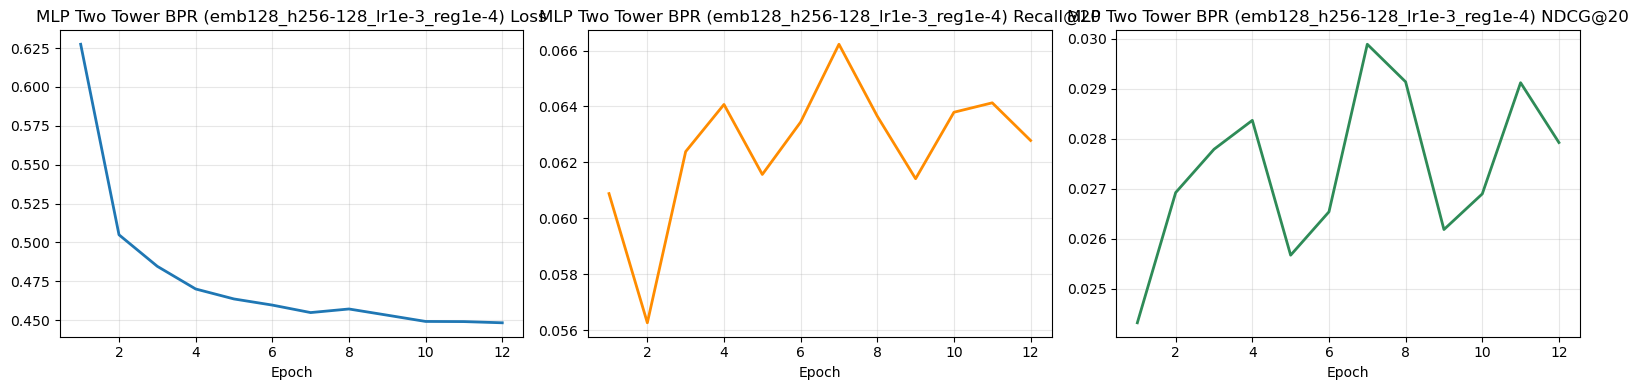

In [7]:

set_global_seed(SEED)
print_section('Training MLP Two Tower BPR')
two_tower_cfg = MODEL_CONFIGS['two_tower_bpr']

def build_two_tower_trial(cfg):
    return MLPTwoTower(n_users, n_items, embedding_dim=cfg['embedding_dim'], hidden_dims=cfg['hidden_dims']).to(device)

def train_two_tower_trial(model, cfg, save_path):
    return train_two_tower_with_val(model, train_df, val_df, cfg, save_path)

def evaluate_two_tower_trial(model, eval_df):
    return evaluate_two_tower(model, eval_df, top_k=TOP_K)

two_tower_best = run_training_trials('two_tower_bpr', 'MLP Two Tower BPR', two_tower_cfg, build_two_tower_trial, train_two_tower_trial, evaluate_two_tower_trial)
two_tower_bpr_model = two_tower_best['model']
two_tower_bpr_history = two_tower_best['history']
two_tower_train_time = two_tower_best['train_time']
two_tower_loaded = two_tower_best['loaded']
record_training_summary('MLP Two Tower BPR', two_tower_bpr_history, two_tower_train_time, loaded_from_checkpoint=two_tower_loaded, selected_trial=two_tower_best['trial_name'])
two_tower_bpr_metrics = evaluate_two_tower(two_tower_bpr_model, test_df, top_k=TOP_K)
append_result('MLP Two Tower BPR', two_tower_bpr_metrics)
display(pd.DataFrame([{'Model': 'MLP Two Tower BPR', 'SelectedTrial': two_tower_best['trial_name'], **two_tower_bpr_metrics}]))
plot_history(two_tower_bpr_history, f"MLP Two Tower BPR ({two_tower_best['trial_name']})")


<a id='section-5-lightgcn-baseline'></a>
##### 5. LightGCN - Baseline



Training LightGCN BPR

LightGCN BPR Trial: emb64_l2_lr1e-3_reg1e-4
Epoch 01 | loss=0.6635 | R@20=0.0048 | N@20=0.0018
Epoch 02 | loss=0.6510 | R@20=0.0108 | N@20=0.0044
Epoch 03 | loss=0.6342 | R@20=0.0211 | N@20=0.0100
Epoch 04 | loss=0.6112 | R@20=0.0341 | N@20=0.0158
Epoch 05 | loss=0.5815 | R@20=0.0470 | N@20=0.0209
Epoch 06 | loss=0.5460 | R@20=0.0550 | N@20=0.0243
Epoch 07 | loss=0.5046 | R@20=0.0616 | N@20=0.0269
Epoch 08 | loss=0.4638 | R@20=0.0651 | N@20=0.0288
Epoch 09 | loss=0.4213 | R@20=0.0684 | N@20=0.0303
Epoch 10 | loss=0.3792 | R@20=0.0706 | N@20=0.0312
Epoch 11 | loss=0.3395 | R@20=0.0721 | N@20=0.0320
Epoch 12 | loss=0.3059 | R@20=0.0741 | N@20=0.0328
Epoch 13 | loss=0.2731 | R@20=0.0748 | N@20=0.0333
Epoch 14 | loss=0.2447 | R@20=0.0760 | N@20=0.0340
Epoch 15 | loss=0.2178 | R@20=0.0772 | N@20=0.0345
Epoch 16 | loss=0.1965 | R@20=0.0785 | N@20=0.0348
Epoch 17 | loss=0.1765 | R@20=0.0795 | N@20=0.0353
Epoch 18 | loss=0.1586 | R@20=0.0801 | N@20=0.0356
Epoch 19 | los

,Model,Trial,ValNDCG@20,ValRecall@20,BestEpoch,EpochsRan,TrainingTimeSec,Checkpoint
4,LightGCN BPR,emb128_l3_lr1e-3_reg1e-4,0.045686,0.101039,35,40,509.107031,c:\Users\ZHIPE\Desktop\Georgia Tech\7643 Deep ...
2,LightGCN BPR,emb64_l4_lr1e-3_reg1e-4,0.042799,0.098657,49,50,603.184936,c:\Users\ZHIPE\Desktop\Georgia Tech\7643 Deep ...
7,LightGCN BPR,emb64_l3_lr1e-3_reg5e-4,0.042647,0.094532,48,50,588.784306,c:\Users\ZHIPE\Desktop\Georgia Tech\7643 Deep ...
6,LightGCN BPR,emb64_l3_lr1e-3_reg5e-5,0.042453,0.096903,45,50,595.607348,c:\Users\ZHIPE\Desktop\Georgia Tech\7643 Deep ...
1,LightGCN BPR,emb64_l3_lr1e-3_reg1e-4,0.042448,0.096309,41,46,574.723212,c:\Users\ZHIPE\Desktop\Georgia Tech\7643 Deep ...
9,LightGCN BPR,emb64_l3_lr1e-3_bs2048,0.041804,0.093538,49,50,570.148721,c:\Users\ZHIPE\Desktop\Georgia Tech\7643 Deep ...
3,LightGCN BPR,emb128_l2_lr1e-3_reg1e-4,0.041357,0.090552,42,47,559.953646,c:\Users\ZHIPE\Desktop\Georgia Tech\7643 Deep ...
5,LightGCN BPR,emb64_l3_lr5e-4_reg1e-4,0.040813,0.095263,48,50,596.663399,c:\Users\ZHIPE\Desktop\Georgia Tech\7643 Deep ...
0,LightGCN BPR,emb64_l2_lr1e-3_reg1e-4,0.038260,0.086197,43,48,601.388467,c:\Users\ZHIPE\Desktop\Georgia Tech\7643 Deep ...
8,LightGCN BPR,emb64_l2_lr5e-4_reg1e-4,0.037283,0.085256,50,50,573.845443,c:\Users\ZHIPE\Desktop\Georgia Tech\7643 Deep ...


,Model,SelectedTrial,NDCG@20,Recall@20,Precision@20,MRR,num_users
0,LightGCN BPR,emb128_l3_lr1e-3_reg1e-4,0.032297,0.070885,0.004403,0.02386,15093


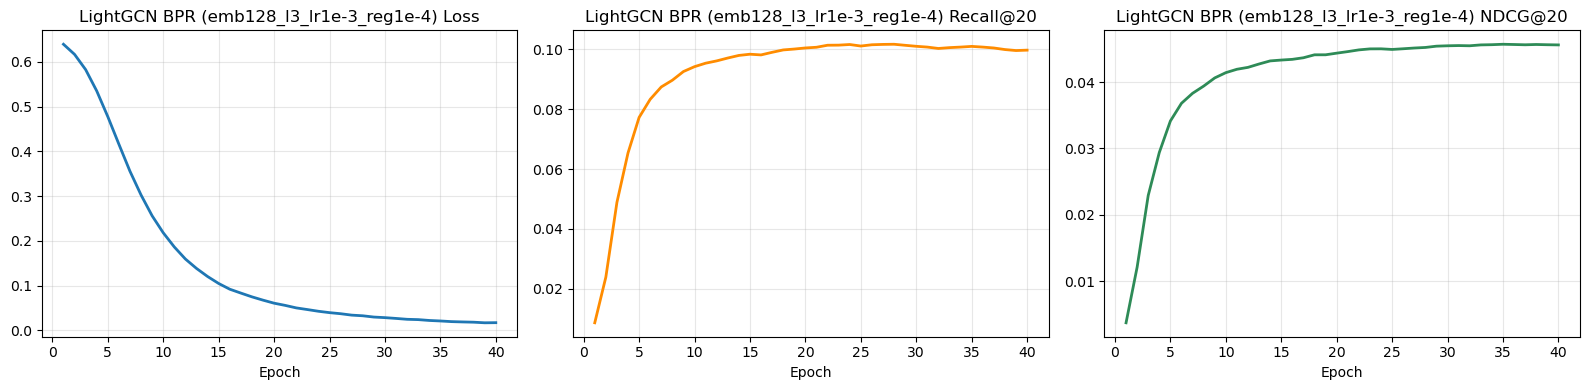

In [8]:

set_global_seed(SEED)
print_section('Training LightGCN BPR')
lightgcn_cfg = MODEL_CONFIGS['lightgcn_bpr']

def build_lightgcn_trial(cfg):
    return LightGCN(n_users, n_items, embedding_dim=cfg['embedding_dim'], n_layers=cfg['n_layers']).to(device)

def train_lightgcn_trial(model, cfg, save_path):
    return train_lightgcn_with_val(model, norm_adj_tensor, train_df, val_df, cfg, save_path)

def evaluate_lightgcn_trial(model, eval_df):
    return evaluate_lightgcn(model, norm_adj_tensor, eval_df, top_k=TOP_K)

lightgcn_best = run_training_trials('lightgcn_bpr', 'LightGCN BPR', lightgcn_cfg, build_lightgcn_trial, train_lightgcn_trial, evaluate_lightgcn_trial)
lightgcn_bpr_model = lightgcn_best['model']
lightgcn_bpr_history = lightgcn_best['history']
lightgcn_train_time = lightgcn_best['train_time']
lightgcn_loaded = lightgcn_best['loaded']
record_training_summary('LightGCN BPR', lightgcn_bpr_history, lightgcn_train_time, loaded_from_checkpoint=lightgcn_loaded, selected_trial=lightgcn_best['trial_name'])
lightgcn_bpr_metrics = evaluate_lightgcn(lightgcn_bpr_model, norm_adj_tensor, test_df, top_k=TOP_K)
append_result('LightGCN BPR', lightgcn_bpr_metrics)
display(pd.DataFrame([{'Model': 'LightGCN BPR', 'SelectedTrial': lightgcn_best['trial_name'], **lightgcn_bpr_metrics}]))
plot_history(lightgcn_bpr_history, f"LightGCN BPR ({lightgcn_best['trial_name']})")


<a id='section-6-ranking-models'></a>
##### 6. Other Ranking Models


<a id='section-6-lightgcl'></a>
##### 6.1 LightGCL


In [9]:
def build_normalized_R(train_df: pd.DataFrame, n_users: int, n_items: int) -> sp.csr_matrix:
    rows = train_df['user_idx'].to_numpy(dtype=np.int64)
    cols = train_df['item_idx'].to_numpy(dtype=np.int64)
    vals = np.ones(len(train_df), dtype=np.float32)
    R = sp.coo_matrix((vals, (rows, cols)), shape=(n_users, n_items)).tocsr()
    user_degree = np.asarray(R.sum(axis=1)).reshape(-1)
    item_degree = np.asarray(R.sum(axis=0)).reshape(-1)
    d_u = np.zeros_like(user_degree, dtype=np.float32)
    d_i = np.zeros_like(item_degree, dtype=np.float32)
    np.power(user_degree, -0.5, out=d_u, where=user_degree > 0)
    np.power(item_degree, -0.5, out=d_i, where=item_degree > 0)
    D_u = sp.diags(d_u)
    D_i = sp.diags(d_i)
    return D_u @ R @ D_i


class LightGCLBPRDataset(Dataset):
    def __init__(self, train_df, n_items):
        self.users = train_df['user_idx'].values.astype(np.int64)
        self.pos = train_df['item_idx'].values.astype(np.int64)
        self.n_items = n_items
        self.user_pos = defaultdict(set)
        for u, i in zip(self.users, self.pos):
            self.user_pos[u].add(i)

    def __len__(self):
        return len(self.users)

    def __getitem__(self, idx):
        u = int(self.users[idx])
        p = int(self.pos[idx])
        while True:
            n = np.random.randint(self.n_items)
            if n not in self.user_pos[u]:
                return u, p, n


class LightGCL(nn.Module):
    def __init__(self, n_users, n_items, U_hat, V_hat, d=64, n_layers=2, dropout=0.0):
        super().__init__()
        self.n_users = n_users
        self.n_items = n_items
        self.n_layers = n_layers
        self.dropout = dropout

        self.E_u_0 = nn.Parameter(torch.empty(n_users, d))
        self.E_i_0 = nn.Parameter(torch.empty(n_items, d))
        nn.init.xavier_uniform_(self.E_u_0)
        nn.init.xavier_uniform_(self.E_i_0)

        self.register_buffer('U_hat', U_hat)
        self.register_buffer('V_hat', V_hat)

    def edge_drop(self, A_hat):
        if self.dropout <= 0 or not self.training:
            return A_hat
        idx = A_hat._indices()
        val = A_hat._values()
        keep = torch.rand_like(val) > self.dropout
        idx = idx[:, keep]
        val = val[keep] / (1 - self.dropout)
        return torch.sparse_coo_tensor(idx, val, A_hat.shape).coalesce()

    def propagate(self, A_hat):
        A = self.edge_drop(A_hat)

        E_u_list = [self.E_u_0]
        E_i_list = [self.E_i_0]
        G_u_list = [self.E_u_0]
        G_i_list = [self.E_i_0]

        for _ in range(self.n_layers):
            E_prev = torch.cat([E_u_list[-1], E_i_list[-1]], dim=0)
            E_next = torch.sparse.mm(A, E_prev)
            E_u_l, E_i_l = torch.split(E_next, [self.n_users, self.n_items], dim=0)
            E_u_list.append(E_u_l)
            E_i_list.append(E_i_l)

            G_u = self.U_hat @ (self.V_hat.t() @ E_i_list[-2])
            G_i = self.V_hat @ (self.U_hat.t() @ E_u_list[-2])
            G_u_list.append(G_u)
            G_i_list.append(G_i)

        E_u = torch.stack(E_u_list, dim=1).mean(dim=1)
        E_i = torch.stack(E_i_list, dim=1).mean(dim=1)
        return E_u, E_i, G_u_list, G_i_list, E_u_list, E_i_list

    def score(self, users, items, E_u, E_i):
        return (E_u[users] * E_i[items]).sum(dim=-1)


def info_nce(z1, z2, all_z2, tau):
    z1 = F.normalize(z1, dim=-1)
    z2 = F.normalize(z2, dim=-1)
    all_z2 = F.normalize(all_z2, dim=-1)
    pos = (z1 * z2).sum(-1) / tau
    logits = z1 @ all_z2.t() / tau
    return -(pos - torch.logsumexp(logits, dim=-1)).mean()


def lightgcl_loss(model, A_hat, users, pos, neg, tau=0.5, lam_cl=0.2, lam_reg=1e-7):
    E_u, E_i, G_u_list, G_i_list, E_u_list, E_i_list = model.propagate(A_hat)

    s_pos = model.score(users, pos, E_u, E_i)
    s_neg = model.score(users, neg, E_u, E_i)
    bpr = -F.logsigmoid(s_pos - s_neg).mean()

    u_uniq = torch.unique(users)
    i_uniq = torch.unique(torch.cat([pos, neg]))

    cl = 0.0
    for l in range(1, model.n_layers + 1):
        cl = cl + info_nce(E_u_list[l][u_uniq], G_u_list[l][u_uniq], E_u_list[l][u_uniq], tau)
        cl = cl + info_nce(G_u_list[l][u_uniq], E_u_list[l][u_uniq], G_u_list[l][u_uniq], tau)
        cl = cl + info_nce(E_i_list[l][i_uniq], G_i_list[l][i_uniq], E_i_list[l][i_uniq], tau)
        cl = cl + info_nce(G_i_list[l][i_uniq], E_i_list[l][i_uniq], G_i_list[l][i_uniq], tau)
    cl = cl / (4 * model.n_layers)

    reg = (
        model.E_u_0[users].pow(2).sum()
        + model.E_i_0[pos].pow(2).sum()
        + model.E_i_0[neg].pow(2).sum()
    ) / users.size(0)

    loss = bpr + lam_cl * cl + lam_reg * reg
    return loss, bpr.item(), cl.item() if torch.is_tensor(cl) else float(cl)



Training LightGCL

LightGCL Trial: emb64_l2_rank5_tau05_cl02
Epoch 01 | loss=2.2691 | R@20=0.0589 | N@20=0.0256
Epoch 02 | loss=2.2216 | R@20=0.0600 | N@20=0.0263
Epoch 03 | loss=2.2168 | R@20=0.0606 | N@20=0.0263
Epoch 04 | loss=2.2136 | R@20=0.0603 | N@20=0.0262
Epoch 05 | loss=2.2120 | R@20=0.0607 | N@20=0.0269
Epoch 06 | loss=2.2104 | R@20=0.0611 | N@20=0.0265
Epoch 07 | loss=2.2081 | R@20=0.0607 | N@20=0.0261
Epoch 08 | loss=2.2046 | R@20=0.0601 | N@20=0.0257
Epoch 09 | loss=2.2004 | R@20=0.0611 | N@20=0.0258
Epoch 10 | loss=2.1941 | R@20=0.0611 | N@20=0.0259
Early stopping triggered.

LightGCL Trial: emb64_l1_rank5_tau05_cl02
Epoch 01 | loss=2.2816 | R@20=0.0592 | N@20=0.0251
Epoch 02 | loss=2.2230 | R@20=0.0590 | N@20=0.0253
Epoch 03 | loss=2.2168 | R@20=0.0590 | N@20=0.0253
Epoch 04 | loss=2.2131 | R@20=0.0592 | N@20=0.0254
Epoch 05 | loss=2.2089 | R@20=0.0589 | N@20=0.0254
Epoch 06 | loss=2.2048 | R@20=0.0588 | N@20=0.0253
Epoch 07 | loss=2.1976 | R@20=0.0586 | N@20=0.0253
Ep

,Model,Trial,ValNDCG@20,ValRecall@20,BestEpoch,EpochsRan,TrainingTimeSec,Checkpoint
9,LightGCL,emb128_l2_rank10_tau05_cl01,0.028657,0.062306,4,9,67.749847,c:\Users\ZHIPE\Desktop\Georgia Tech\7643 Deep ...
2,LightGCL,emb64_l3_rank5_tau05_cl02,0.028538,0.061658,1,6,45.776674,c:\Users\ZHIPE\Desktop\Georgia Tech\7643 Deep ...
5,LightGCL,emb64_l2_rank5_tau02_cl02,0.027907,0.059573,2,7,51.995634,c:\Users\ZHIPE\Desktop\Georgia Tech\7643 Deep ...
7,LightGCL,emb64_l2_rank5_tau05_cl01,0.027800,0.059093,2,7,52.422902,c:\Users\ZHIPE\Desktop\Georgia Tech\7643 Deep ...
4,LightGCL,emb64_l2_rank20_tau05_cl02,0.027740,0.060697,2,7,53.279014,c:\Users\ZHIPE\Desktop\Georgia Tech\7643 Deep ...
3,LightGCL,emb64_l2_rank10_tau05_cl02,0.027233,0.059504,2,7,52.094040,c:\Users\ZHIPE\Desktop\Georgia Tech\7643 Deep ...
0,LightGCL,emb64_l2_rank5_tau05_cl02,0.026894,0.060664,5,10,74.734316,c:\Users\ZHIPE\Desktop\Georgia Tech\7643 Deep ...
6,LightGCL,emb64_l2_rank5_tau10_cl02,0.026307,0.058971,1,6,44.200966,c:\Users\ZHIPE\Desktop\Georgia Tech\7643 Deep ...
1,LightGCL,emb64_l1_rank5_tau05_cl02,0.025411,0.059162,4,9,64.010705,c:\Users\ZHIPE\Desktop\Georgia Tech\7643 Deep ...
8,LightGCL,emb64_l2_rank5_tau05_cl005,0.025347,0.059593,6,11,82.823287,c:\Users\ZHIPE\Desktop\Georgia Tech\7643 Deep ...


,Model,SelectedTrial,NDCG@20,Recall@20,Precision@20,MRR,num_users
0,LightGCL,emb128_l2_rank10_tau05_cl01,0.027367,0.050068,0.003097,0.02322,15093


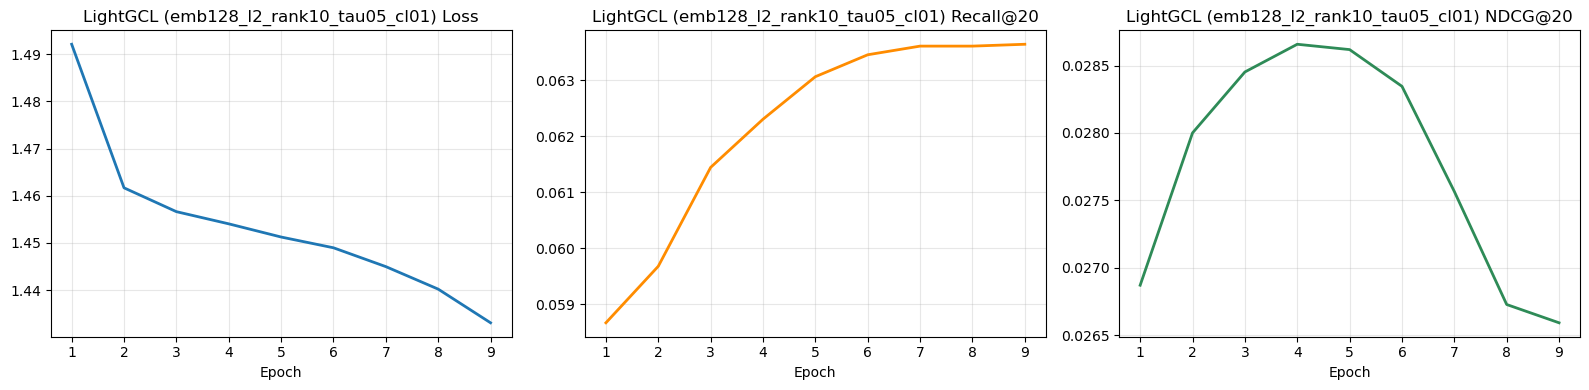

In [10]:
set_global_seed(SEED)
print_section('Training LightGCL')

def evaluate_lightgcl_metrics(model, A_hat, eval_df, top_k=TOP_K):
    model.eval()
    with torch.no_grad():
        E_u, E_i, *_ = model.propagate(A_hat)
    return compute_metrics_from_score_fn(lambda user_idx: E_u[user_idx] @ E_i.t(), eval_df, user_positive_items, top_k=top_k)

def train_lightgcl_with_val(model, A_hat, loader, val_df, cfg, save_path):
    optimizer = torch.optim.Adam(model.parameters(), lr=cfg['lr'])
    best_ndcg, best_recall, patience_counter = -float('inf'), -float('inf'), 0
    history = []
    for epoch in range(EPOCHS):
        model.train()
        total_loss, n_batches = 0.0, 0
        for users, pos, neg in loader:
            users, pos, neg = users.to(device), pos.to(device), neg.to(device)
            optimizer.zero_grad()
            loss, _, _ = lightgcl_loss(model, A_hat, users, pos, neg, tau=cfg['tau'], lam_cl=cfg['lam_cl'], lam_reg=cfg['lam_reg'])
            loss.backward()
            optimizer.step()
            total_loss += loss.item()
            n_batches += 1
        train_loss = total_loss / max(1, n_batches)
        val_metrics = evaluate_lightgcl_metrics(model, A_hat, val_df, top_k=TOP_K)
        val_ndcg, val_recall = val_metrics[f'NDCG@{TOP_K}'], val_metrics[f'Recall@{TOP_K}']
        history.append({'epoch': epoch + 1, 'train_loss': train_loss, f'val_ndcg@{TOP_K}': val_ndcg, f'val_recall@{TOP_K}': val_recall})
        print(f"Epoch {epoch+1:02d} | loss={train_loss:.4f} | R@{TOP_K}={val_recall:.4f} | N@{TOP_K}={val_ndcg:.4f}")
        if val_ndcg > best_ndcg or (val_ndcg == best_ndcg and val_recall > best_recall):
            best_ndcg, best_recall, patience_counter = val_ndcg, val_recall, 0
            torch.save(model.state_dict(), save_path)
        else:
            patience_counter += 1
            if patience_counter >= PATIENCE:
                print('Early stopping triggered.')
                break
    return history

lightgcl_cfg = MODEL_CONFIGS['lightgcl']
normalized_R = build_normalized_R(train_df, n_users, n_items)
lightgcl_factor_cache = {}

def get_lightgcl_factors(cfg):
    svd_rank = min(int(cfg['svd_rank']), max(1, min(normalized_R.shape) - 1))
    if svd_rank not in lightgcl_factor_cache:
        U_hat_np, s_vals, Vt_hat_np = svds(normalized_R.astype(np.float32), k=svd_rank)
        sort_idx = np.argsort(-s_vals)
        lightgcl_factor_cache[svd_rank] = (
            torch.tensor(U_hat_np[:, sort_idx], dtype=torch.float32, device=device),
            torch.tensor(Vt_hat_np[sort_idx, :].T, dtype=torch.float32, device=device),
        )
    return lightgcl_factor_cache[svd_rank]

def build_lightgcl_trial(cfg):
    U_hat, V_hat = get_lightgcl_factors(cfg)
    return LightGCL(n_users, n_items, U_hat, V_hat, d=cfg['embedding_dim'], n_layers=cfg['n_layers'], dropout=cfg['dropout']).to(device)

def train_lightgcl_trial(model, cfg, save_path):
    loader = DataLoader(LightGCLBPRDataset(train_df, n_items), batch_size=cfg['batch_size'], shuffle=True, num_workers=0)
    return train_lightgcl_with_val(model, norm_adj_tensor, loader, val_df, cfg, save_path)

def evaluate_lightgcl_trial(model, eval_df):
    return evaluate_lightgcl_metrics(model, norm_adj_tensor, eval_df, top_k=TOP_K)

lightgcl_best = run_training_trials('lightgcl', 'LightGCL', lightgcl_cfg, build_lightgcl_trial, train_lightgcl_trial, evaluate_lightgcl_trial)
lightgcl_model = lightgcl_best['model']
lightgcl_history = lightgcl_best['history']
lightgcl_train_time = lightgcl_best['train_time']
lightgcl_loaded = lightgcl_best['loaded']
record_training_summary('LightGCL', lightgcl_history, lightgcl_train_time, loaded_from_checkpoint=lightgcl_loaded, selected_trial=lightgcl_best['trial_name'])
lightgcl_metrics = evaluate_lightgcl_metrics(lightgcl_model, norm_adj_tensor, test_df, top_k=TOP_K)
append_result('LightGCL', lightgcl_metrics)
display(pd.DataFrame([{'Model': 'LightGCL', 'SelectedTrial': lightgcl_best['trial_name'], **lightgcl_metrics}]))
plot_history(lightgcl_history, f"LightGCL ({lightgcl_best['trial_name']})")


<a id='section-6-gatv2'></a>
##### 6.2 GATv2



Training GATv2

GATv2 Trial: emb64_l2_h4_lr1e-3_drop0
Epoch 01 | loss=0.6555 | R@20=0.0395 | N@20=0.0126
Epoch 02 | loss=0.4724 | R@20=0.0513 | N@20=0.0191
Epoch 03 | loss=0.3793 | R@20=0.0401 | N@20=0.0129
Epoch 04 | loss=0.3628 | R@20=0.0525 | N@20=0.0196
Epoch 05 | loss=0.3569 | R@20=0.0505 | N@20=0.0222
Epoch 06 | loss=0.3471 | R@20=0.0516 | N@20=0.0220
Epoch 07 | loss=0.3472 | R@20=0.0566 | N@20=0.0214
Epoch 08 | loss=0.3444 | R@20=0.0574 | N@20=0.0229
Epoch 09 | loss=0.3413 | R@20=0.0491 | N@20=0.0198
Epoch 10 | loss=0.3408 | R@20=0.0492 | N@20=0.0197
Epoch 11 | loss=0.3373 | R@20=0.0483 | N@20=0.0190
Epoch 12 | loss=0.3290 | R@20=0.0540 | N@20=0.0243
Epoch 13 | loss=0.3120 | R@20=0.0533 | N@20=0.0220
Epoch 14 | loss=0.3010 | R@20=0.0430 | N@20=0.0163
Epoch 15 | loss=0.2862 | R@20=0.0430 | N@20=0.0167
Epoch 16 | loss=0.2742 | R@20=0.0384 | N@20=0.0155
Epoch 17 | loss=0.2620 | R@20=0.0360 | N@20=0.0145
Early stopping triggered.

GATv2 Trial: emb64_l1_h4_lr1e-3_drop0
Epoch 01 | lo

,Model,Trial,ValNDCG@20,ValRecall@20,BestEpoch,EpochsRan,TrainingTimeSec,Checkpoint
8,GATv2,emb128_l2_h4_lr5e-4_drop0,0.026666,0.058450,12,17,164.011811,c:\Users\ZHIPE\Desktop\Georgia Tech\7643 Deep ...
4,GATv2,emb64_l2_h8_lr1e-3_drop0,0.026658,0.057329,12,17,162.713862,c:\Users\ZHIPE\Desktop\Georgia Tech\7643 Deep ...
5,GATv2,emb64_l2_h4_lr5e-4_drop0,0.026568,0.057467,15,20,170.474100,c:\Users\ZHIPE\Desktop\Georgia Tech\7643 Deep ...
2,GATv2,emb64_l3_h4_lr1e-3_drop0,0.026362,0.057900,8,13,116.438658,c:\Users\ZHIPE\Desktop\Georgia Tech\7643 Deep ...
7,GATv2,emb64_l2_h4_lr1e-3_l2_5e-5,0.025519,0.056666,11,16,135.357105,c:\Users\ZHIPE\Desktop\Georgia Tech\7643 Deep ...
9,GATv2,emb64_l2_h4_lr1e-3_bs2048,0.025097,0.054725,14,19,157.138136,c:\Users\ZHIPE\Desktop\Georgia Tech\7643 Deep ...
0,GATv2,emb64_l2_h4_lr1e-3_drop0,0.024298,0.053963,12,17,140.923630,c:\Users\ZHIPE\Desktop\Georgia Tech\7643 Deep ...
6,GATv2,emb64_l2_h4_lr1e-3_drop01,0.022190,0.055297,15,20,169.471680,c:\Users\ZHIPE\Desktop\Georgia Tech\7643 Deep ...
1,GATv2,emb64_l1_h4_lr1e-3_drop0,0.020719,0.053081,9,14,107.273988,c:\Users\ZHIPE\Desktop\Georgia Tech\7643 Deep ...
3,GATv2,emb64_l2_h2_lr1e-3_drop0,0.017898,0.047067,2,7,54.340881,c:\Users\ZHIPE\Desktop\Georgia Tech\7643 Deep ...


,Model,SelectedTrial,NDCG@20,Recall@20,Precision@20,MRR,num_users
0,GATv2,emb128_l2_h4_lr5e-4_drop0,0.026023,0.047402,0.002958,0.022247,15093


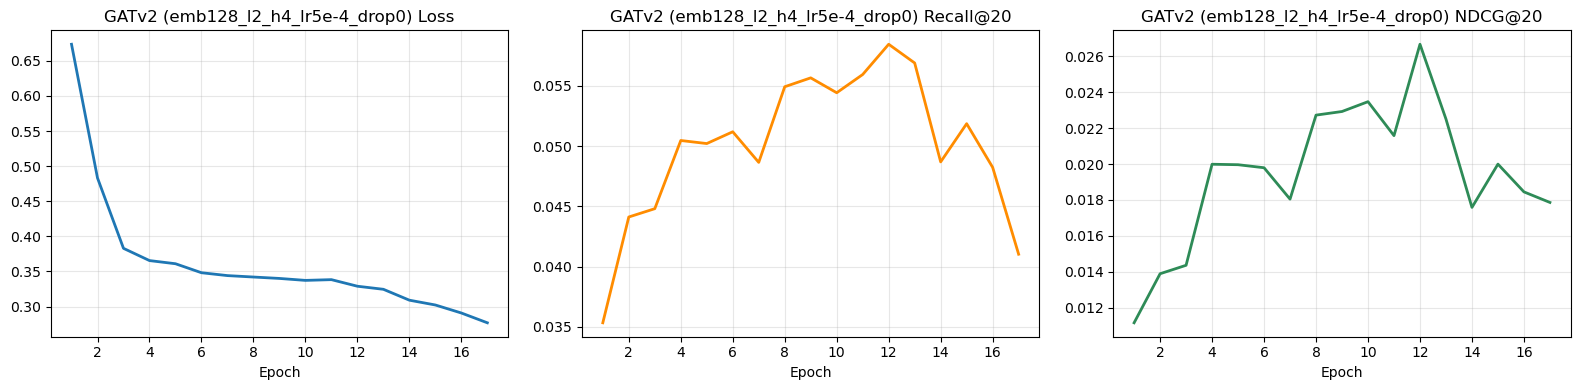

In [11]:
set_global_seed(SEED)
print_section('Training GATv2')

if not HAS_TORCH_GEOMETRIC:
    print('Skipping GATv2 because torch_geometric is not installed.')
    print(GATV2_IMPORT_ERROR)
    gat_metrics = None
    gat_history = []
    record_training_summary('GATv2', gat_history, 0.0, skipped=True)
else:
    def build_edge_index_from_train_df(train_df, n_users, n_items):
        user_indices = train_df['user_idx'].to_numpy(dtype=np.int64)
        item_indices = train_df['item_idx'].to_numpy(dtype=np.int64)
        row = np.concatenate([user_indices, item_indices + n_users])
        col = np.concatenate([item_indices + n_users, user_indices])
        return torch.LongTensor(np.vstack([row, col])).to(device)

    class GATOriginalBPRDataset(Dataset):
        def __init__(self, train_df, n_items):
            self.users = train_df['user_idx'].values.astype(np.int64)
            self.pos_items = train_df['item_idx'].values.astype(np.int64)
            self.n_items = n_items
            self.user_pos = defaultdict(set)
            for u, i in zip(self.users, self.pos_items):
                self.user_pos[u].add(i)
        def __len__(self):
            return len(self.users)
        def __getitem__(self, idx):
            u = int(self.users[idx])
            pos = int(self.pos_items[idx])
            while True:
                neg = np.random.randint(self.n_items)
                if neg not in self.user_pos[u]:
                    break
            return u, pos, neg

    class GATCF(nn.Module):
        def __init__(self, n_users, n_items, embedding_dim=64, n_layers=2, n_heads=4, dropout=0.0):
            super().__init__()
            self.n_users = n_users
            self.n_items = n_items
            self.user_emb = nn.Embedding(n_users, embedding_dim)
            self.item_emb = nn.Embedding(n_items, embedding_dim)
            nn.init.normal_(self.user_emb.weight, std=0.1)
            nn.init.normal_(self.item_emb.weight, std=0.1)
            self.gat_layers = nn.ModuleList([
                GATv2Conv(embedding_dim, embedding_dim, heads=n_heads, concat=False, dropout=dropout, add_self_loops=True)
                for _ in range(n_layers)
            ])
        def propagate(self, edge_index):
            x = torch.cat([self.user_emb.weight, self.item_emb.weight], dim=0)
            for i, layer in enumerate(self.gat_layers):
                x = layer(x, edge_index)
                if i < len(self.gat_layers) - 1:
                    x = F.elu(x)
            return torch.split(x, [self.n_users, self.n_items], dim=0)
        def bpr_loss(self, users, pos, neg, edge_index, l2_reg=1e-4):
            users_out, items_out = self.propagate(edge_index)
            u_e, p_e, n_e = users_out[users], items_out[pos], items_out[neg]
            bpr = -F.logsigmoid((u_e * p_e).sum(-1) - (u_e * n_e).sum(-1)).mean()
            reg = (self.user_emb(users).pow(2).sum() + self.item_emb(pos).pow(2).sum() + self.item_emb(neg).pow(2).sum()) / users.size(0)
            return bpr + l2_reg * 0.5 * reg, bpr.item()

    def evaluate_gat_metrics(model, edge_index, eval_df, top_k=TOP_K):
        model.eval()
        with torch.no_grad():
            users_out, items_out = model.propagate(edge_index)
        return compute_metrics_from_score_fn(lambda user_idx: users_out[user_idx] @ items_out.T, eval_df, user_positive_items, top_k=top_k)

    def train_gat_with_val(model, edge_index, loader, val_df, cfg, save_path):
        optimizer = torch.optim.Adam(model.parameters(), lr=cfg['lr'])
        best_ndcg, best_recall, patience_counter = -float('inf'), -float('inf'), 0
        history = []
        for epoch in range(EPOCHS):
            model.train()
            total_loss, n_batches = 0.0, 0
            for users, pos, neg in loader:
                users, pos, neg = users.to(device), pos.to(device), neg.to(device)
                optimizer.zero_grad()
                loss, _ = model.bpr_loss(users, pos, neg, edge_index, l2_reg=cfg['l2_reg'])
                loss.backward()
                optimizer.step()
                total_loss += loss.item()
                n_batches += 1
            train_loss = total_loss / max(1, n_batches)
            val_metrics = evaluate_gat_metrics(model, edge_index, val_df, top_k=TOP_K)
            val_ndcg, val_recall = val_metrics[f'NDCG@{TOP_K}'], val_metrics[f'Recall@{TOP_K}']
            history.append({'epoch': epoch + 1, 'train_loss': train_loss, f'val_ndcg@{TOP_K}': val_ndcg, f'val_recall@{TOP_K}': val_recall})
            print(f"Epoch {epoch+1:02d} | loss={train_loss:.4f} | R@{TOP_K}={val_recall:.4f} | N@{TOP_K}={val_ndcg:.4f}")
            if val_ndcg > best_ndcg or (val_ndcg == best_ndcg and val_recall > best_recall):
                best_ndcg, best_recall, patience_counter = val_ndcg, val_recall, 0
                torch.save(model.state_dict(), save_path)
            else:
                patience_counter += 1
                if patience_counter >= PATIENCE:
                    print('Early stopping triggered.')
                    break
        return history

    gat_cfg = MODEL_CONFIGS['gatv2']
    edge_index = build_edge_index_from_train_df(train_df, n_users, n_items)

    def build_gat_trial(cfg):
        return GATCF(n_users, n_items, embedding_dim=cfg['embedding_dim'], n_layers=cfg['n_layers'], n_heads=cfg['n_heads'], dropout=cfg['dropout']).to(device)

    def train_gat_trial(model, cfg, save_path):
        loader = DataLoader(GATOriginalBPRDataset(train_df, n_items), batch_size=cfg['batch_size'], shuffle=True, num_workers=0)
        return train_gat_with_val(model, edge_index, loader, val_df, cfg, save_path)

    def evaluate_gat_trial(model, eval_df):
        return evaluate_gat_metrics(model, edge_index, eval_df, top_k=TOP_K)

    gat_best = run_training_trials('gatv2', 'GATv2', gat_cfg, build_gat_trial, train_gat_trial, evaluate_gat_trial)
    gat_model = gat_best['model']
    gat_history = gat_best['history']
    gat_train_time = gat_best['train_time']
    gat_loaded = gat_best['loaded']
    record_training_summary('GATv2', gat_history, gat_train_time, loaded_from_checkpoint=gat_loaded, selected_trial=gat_best['trial_name'])
    gat_metrics = evaluate_gat_metrics(gat_model, edge_index, test_df, top_k=TOP_K)
    append_result('GATv2', gat_metrics)
    display(pd.DataFrame([{'Model': 'GATv2', 'SelectedTrial': gat_best['trial_name'], **gat_metrics}]))
    plot_history(gat_history, f"GATv2 ({gat_best['trial_name']})")


<a id='section-6-graphsage'></a>
##### 6.3 GraphSAGE


In [16]:
class GraphSAGELayer(nn.Module):
    def __init__(self, in_dim, out_dim, dropout=0.2):
        super(GraphSAGELayer, self).__init__()
        self.linear = nn.Linear(in_dim * 2, out_dim)
        self.dropout = nn.Dropout(dropout)

    def forward(self, x, norm_adj):
        neigh = torch.sparse.mm(norm_adj, x)
        out = torch.cat([x, neigh], dim=1)
        out = self.linear(out)
        out = F.relu(out)
        out = self.dropout(out)
        return out


class GraphSAGERecommender(nn.Module):
    """
    GraphSAGE-style recommender for top-K ranking on a user-item bipartite graph.

    The model returns raw relevance scores instead of explicit rating predictions.
    This is intentional for ranking with BPR loss.
    """
    def __init__(self, n_users, n_items, embedding_dim=64, hidden_dim=64, n_layers=2, dropout=0.2):
        super(GraphSAGERecommender, self).__init__()
        self.n_users = n_users
        self.n_items = n_items
        self.embedding_dim = embedding_dim

        self.user_embedding = nn.Embedding(n_users, embedding_dim)
        self.item_embedding = nn.Embedding(n_items, embedding_dim)

        self.layers = nn.ModuleList()
        input_dim = embedding_dim
        for _ in range(n_layers):
            self.layers.append(GraphSAGELayer(input_dim, hidden_dim, dropout=dropout))
            input_dim = hidden_dim

        # Bias terms are useful for recommendation ranking, but scores stay unbounded.
        self.user_bias = nn.Embedding(n_users, 1)
        self.item_bias = nn.Embedding(n_items, 1)
        self.global_bias = nn.Parameter(torch.zeros(1))

        self._init_weights()

    def _init_weights(self):
        nn.init.normal_(self.user_embedding.weight, std=0.1)
        nn.init.normal_(self.item_embedding.weight, std=0.1)
        nn.init.zeros_(self.user_bias.weight)
        nn.init.zeros_(self.item_bias.weight)

    def get_all_embeddings(self, norm_adj):
        x = torch.cat([self.user_embedding.weight, self.item_embedding.weight], dim=0)
        representations = [x]

        for layer in self.layers:
            x = layer(x, norm_adj)
            representations.append(x)

        # Average initial and propagated embeddings.
        final_x = torch.stack(representations, dim=0).mean(dim=0)
        user_x = final_x[:self.n_users]
        item_x = final_x[self.n_users:]
        return user_x, item_x

    def score_pairs(self, users, items, norm_adj):
        user_x, item_x = self.get_all_embeddings(norm_adj)
        user_vec = user_x[users]
        item_vec = item_x[items]

        scores = (user_vec * item_vec).sum(dim=1)
        scores = scores + self.user_bias(users).squeeze(-1) + self.item_bias(items).squeeze(-1) + self.global_bias
        return scores

    def score_pairs_from_embeddings(self, user_x, item_x, users, items):
        user_vec = user_x[users]
        item_vec = item_x[items]
        scores = (user_vec * item_vec).sum(dim=1)
        scores = scores + self.user_bias(users).squeeze(-1) + self.item_bias(items).squeeze(-1) + self.global_bias
        return scores

    def forward(self, users, items, norm_adj):
        return self.score_pairs(users, items, norm_adj)



Training GraphSAGE

GraphSAGE Trial: emb256_h256_l2_drop02_lr1e-3
Epoch 01 | loss=0.5496 | R@20=0.0608 | N@20=0.0261
Epoch 02 | loss=0.4826 | R@20=0.0581 | N@20=0.0229
Epoch 03 | loss=0.4532 | R@20=0.0553 | N@20=0.0216
Epoch 04 | loss=0.4281 | R@20=0.0606 | N@20=0.0252
Epoch 05 | loss=0.4139 | R@20=0.0566 | N@20=0.0237
Epoch 06 | loss=0.3734 | R@20=0.0562 | N@20=0.0225
Early stopping triggered.

GraphSAGE Trial: emb128_h128_l2_drop02_lr1e-3
Epoch 01 | loss=0.5927 | R@20=0.0591 | N@20=0.0274
Epoch 02 | loss=0.4862 | R@20=0.0596 | N@20=0.0273
Epoch 03 | loss=0.4547 | R@20=0.0582 | N@20=0.0217
Epoch 04 | loss=0.4379 | R@20=0.0560 | N@20=0.0241
Epoch 05 | loss=0.4233 | R@20=0.0534 | N@20=0.0240
Epoch 06 | loss=0.4139 | R@20=0.0548 | N@20=0.0263
Early stopping triggered.

GraphSAGE Trial: emb256_h128_l2_drop02_lr1e-3
GraphSAGE requires hidden_dim == embedding_dim for representation averaging; overriding hidden_dim 128 -> 256.
Epoch 01 | loss=0.5586 | R@20=0.0605 | N@20=0.0262
Epoch 02 | lo

,Model,Trial,ValNDCG@20,ValRecall@20,BestEpoch,EpochsRan,TrainingTimeSec,Checkpoint
8,GraphSAGE,emb256_h256_l2_drop02_lr5e-4,0.028063,0.062652,2,7,75.261208,c:\Users\ZHIPE\Desktop\Georgia Tech\7643 Deep ...
6,GraphSAGE,emb256_h256_l2_drop01_lr1e-3,0.027672,0.057502,1,6,68.258133,c:\Users\ZHIPE\Desktop\Georgia Tech\7643 Deep ...
1,GraphSAGE,emb128_h128_l2_drop02_lr1e-3,0.027442,0.059096,1,6,54.250854,c:\Users\ZHIPE\Desktop\Georgia Tech\7643 Deep ...
7,GraphSAGE,emb256_h256_l2_drop03_lr1e-3,0.026640,0.057208,1,6,64.590969,c:\Users\ZHIPE\Desktop\Georgia Tech\7643 Deep ...
9,GraphSAGE,emb256_h256_l2_drop02_reg5e-5,0.026521,0.055477,5,10,107.628792,c:\Users\ZHIPE\Desktop\Georgia Tech\7643 Deep ...
4,GraphSAGE,emb256_h256_l1_drop02_lr1e-3,0.026441,0.058254,3,8,98.031980,c:\Users\ZHIPE\Desktop\Georgia Tech\7643 Deep ...
3,GraphSAGE,emb128_h256_l2_drop02_lr1e-3,0.026299,0.057221,5,10,120.272822,c:\Users\ZHIPE\Desktop\Georgia Tech\7643 Deep ...
2,GraphSAGE,emb256_h128_l2_drop02_lr1e-3,0.026251,0.060780,2,7,78.700737,c:\Users\ZHIPE\Desktop\Georgia Tech\7643 Deep ...
0,GraphSAGE,emb256_h256_l2_drop02_lr1e-3,0.026061,0.060769,1,6,56.576418,c:\Users\ZHIPE\Desktop\Georgia Tech\7643 Deep ...
5,GraphSAGE,emb256_h256_l3_drop02_lr1e-3,0.025938,0.059372,1,6,80.522445,c:\Users\ZHIPE\Desktop\Georgia Tech\7643 Deep ...


,Model,SelectedTrial,NDCG@20,Recall@20,Precision@20,MRR,num_users
0,GraphSAGE,emb256_h256_l2_drop02_lr5e-4,0.027423,0.051717,0.003177,0.022817,15093


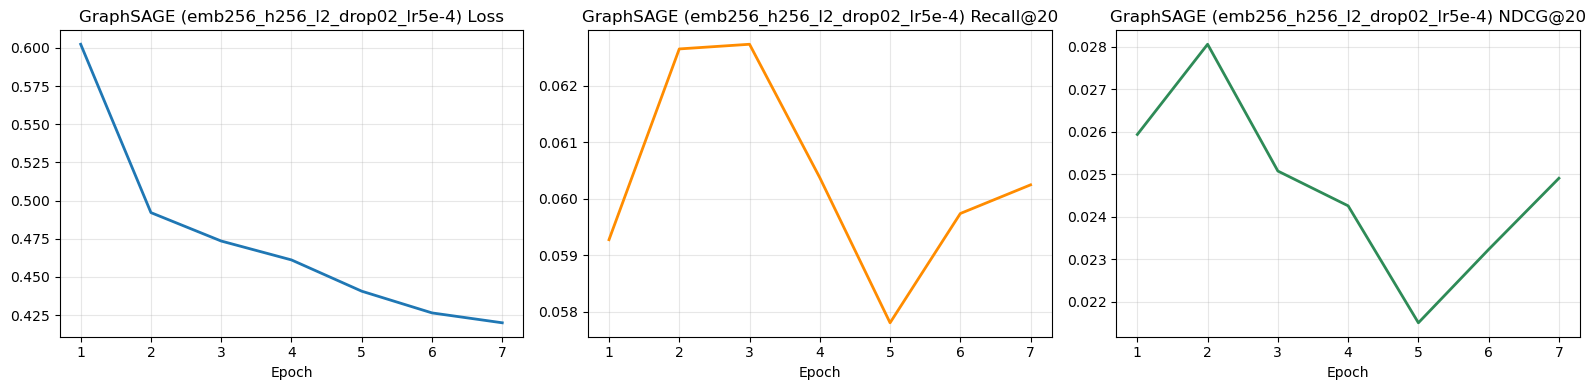

In [17]:
set_global_seed(SEED)
print_section('Training GraphSAGE')

def graphsage_bpr_loss(pos_scores, neg_scores):
    return -torch.log(torch.sigmoid(pos_scores - neg_scores) + 1e-8).mean()

def train_graphsage_bpr_epoch(model, norm_adj, train_df, user_positive_items, num_items, optimizer, batch_size, device, reg_weight=1e-5):
    model.train()
    total_loss = 0.0
    num_steps = int(np.ceil(len(train_df) / batch_size))
    for _ in range(num_steps):
        users, pos_items, neg_items = sample_bpr_batch(train_df, user_positive_items, num_items, batch_size)
        users, pos_items, neg_items = users.to(device), pos_items.to(device), neg_items.to(device)
        pos_scores = model(users, pos_items, norm_adj)
        neg_scores = model(users, neg_items, norm_adj)
        loss = graphsage_bpr_loss(pos_scores, neg_scores)
        reg_loss = reg_weight * (model.user_embedding(users).pow(2).sum() + model.item_embedding(pos_items).pow(2).sum() + model.item_embedding(neg_items).pow(2).sum()) / len(users)
        total = loss + reg_loss
        optimizer.zero_grad()
        total.backward()
        optimizer.step()
        total_loss += total.item()
    return total_loss / max(1, num_steps)

def evaluate_graphsage_metrics(model, norm_adj, eval_df, top_k=TOP_K):
    model.eval()
    all_items = torch.arange(n_items, device=device)
    with torch.no_grad():
        user_x, item_x = model.get_all_embeddings(norm_adj)
    def score_fn(user_idx):
        user_tensor = torch.LongTensor([user_idx]).to(device)
        scores = torch.matmul(item_x, user_x[user_idx])
        scores = scores + model.item_bias(all_items).squeeze(-1) + model.user_bias(user_tensor).squeeze(-1) + model.global_bias
        return scores
    return compute_metrics_from_score_fn(score_fn, eval_df, user_positive_items, top_k=top_k)

def train_graphsage_with_val(model, norm_adj, train_df, val_df, cfg, save_path):
    optimizer = torch.optim.Adam(model.parameters(), lr=cfg['lr'], weight_decay=0.0)
    best_ndcg, best_recall, patience_counter = -float('inf'), -float('inf'), 0
    history = []
    for epoch in range(EPOCHS):
        train_loss = train_graphsage_bpr_epoch(model, norm_adj, train_df, user_positive_items, n_items, optimizer, cfg['batch_size'], device, reg_weight=cfg['reg_weight'])
        val_metrics = evaluate_graphsage_metrics(model, norm_adj, val_df, top_k=TOP_K)
        val_ndcg, val_recall = val_metrics[f'NDCG@{TOP_K}'], val_metrics[f'Recall@{TOP_K}']
        history.append({'epoch': epoch + 1, 'train_loss': train_loss, f'val_ndcg@{TOP_K}': val_ndcg, f'val_recall@{TOP_K}': val_recall})
        print(f"Epoch {epoch+1:02d} | loss={train_loss:.4f} | R@{TOP_K}={val_recall:.4f} | N@{TOP_K}={val_ndcg:.4f}")
        if val_ndcg > best_ndcg or (val_ndcg == best_ndcg and val_recall > best_recall):
            best_ndcg, best_recall, patience_counter = val_ndcg, val_recall, 0
            torch.save(model.state_dict(), save_path)
        else:
            patience_counter += 1
            if patience_counter >= PATIENCE:
                print('Early stopping triggered.')
                break
    return history

graphsage_cfg = MODEL_CONFIGS['graphsage']

def build_graphsage_trial(cfg):
    cfg = dict(cfg)
    if cfg['hidden_dim'] != cfg['embedding_dim']:
        print(f"GraphSAGE requires hidden_dim == embedding_dim for representation averaging; overriding hidden_dim {cfg['hidden_dim']} -> {cfg['embedding_dim']}.")
        cfg['hidden_dim'] = cfg['embedding_dim']
    return GraphSAGERecommender(n_users=n_users, n_items=n_items, embedding_dim=cfg['embedding_dim'], hidden_dim=cfg['hidden_dim'], n_layers=cfg['n_layers'], dropout=cfg['dropout']).to(device)

def train_graphsage_trial(model, cfg, save_path):
    return train_graphsage_with_val(model, norm_adj_tensor, train_df, val_df, cfg, save_path)

def evaluate_graphsage_trial(model, eval_df):
    return evaluate_graphsage_metrics(model, norm_adj_tensor, eval_df, top_k=TOP_K)

graphsage_best = run_training_trials('graphsage', 'GraphSAGE', graphsage_cfg, build_graphsage_trial, train_graphsage_trial, evaluate_graphsage_trial)
graphsage_model = graphsage_best['model']
graphsage_history = graphsage_best['history']
graphsage_train_time = graphsage_best['train_time']
graphsage_loaded = graphsage_best['loaded']
record_training_summary('GraphSAGE', graphsage_history, graphsage_train_time, loaded_from_checkpoint=graphsage_loaded, selected_trial=graphsage_best['trial_name'])
graphsage_metrics = evaluate_graphsage_metrics(graphsage_model, norm_adj_tensor, test_df, top_k=TOP_K)
append_result('GraphSAGE', graphsage_metrics)
display(pd.DataFrame([{'Model': 'GraphSAGE', 'SelectedTrial': graphsage_best['trial_name'], **graphsage_metrics}]))
plot_history(graphsage_history, f"GraphSAGE ({graphsage_best['trial_name']})")


<a id='section-6-svd-graph-fusion'></a>
##### 6.4 SVD Graph Fusion


Training SVD Graph Fusion From Scratch

SVD Graph Fusion From Scratch Trial: rank64_top10_w005
Epoch 01 | loss=0.6731 | R@20=0.0027 | N@20=0.0010
Epoch 02 | loss=0.6710 | R@20=0.0036 | N@20=0.0013
Epoch 03 | loss=0.6688 | R@20=0.0050 | N@20=0.0020
Epoch 04 | loss=0.6663 | R@20=0.0074 | N@20=0.0032
Epoch 05 | loss=0.6628 | R@20=0.0110 | N@20=0.0051
Epoch 06 | loss=0.6594 | R@20=0.0168 | N@20=0.0080
Epoch 07 | loss=0.6549 | R@20=0.0243 | N@20=0.0115
Epoch 08 | loss=0.6502 | R@20=0.0339 | N@20=0.0157
Epoch 09 | loss=0.6442 | R@20=0.0432 | N@20=0.0198
Epoch 10 | loss=0.6376 | R@20=0.0510 | N@20=0.0230
Epoch 11 | loss=0.6296 | R@20=0.0573 | N@20=0.0255
Epoch 12 | loss=0.6203 | R@20=0.0631 | N@20=0.0277
Epoch 13 | loss=0.6106 | R@20=0.0668 | N@20=0.0292
Epoch 14 | loss=0.5993 | R@20=0.0696 | N@20=0.0303
Epoch 15 | loss=0.5867 | R@20=0.0718 | N@20=0.0313
Epoch 16 | loss=0.5741 | R@20=0.0735 | N@20=0.0321
Epoch 17 | loss=0.5596 | R@20=0.0747 | N@20=0.0325
Epoch 18 | loss=0.5444 | R@20=0.0751 

,Model,Trial,ValNDCG@20,ValRecall@20,BestEpoch,EpochsRan,TrainingTimeSec,Checkpoint
9,SVD Graph Fusion Scratch,rank64_top10_w005_reg5e-4,0.038660,0.088806,48,50,610.306028,c:\Users\ZHIPE\Desktop\Georgia Tech\7643 Deep ...
7,SVD Graph Fusion Scratch,rank128_top10_w005,0.038609,0.088696,50,50,611.427413,c:\Users\ZHIPE\Desktop\Georgia Tech\7643 Deep ...
0,SVD Graph Fusion Scratch,rank64_top10_w005,0.037955,0.087445,50,50,606.763755,c:\Users\ZHIPE\Desktop\Georgia Tech\7643 Deep ...
6,SVD Graph Fusion Scratch,rank32_top10_w005,0.037067,0.085052,50,50,607.954427,c:\Users\ZHIPE\Desktop\Georgia Tech\7643 Deep ...
1,SVD Graph Fusion Scratch,rank64_top10_w010,0.036284,0.083227,50,50,599.838327,c:\Users\ZHIPE\Desktop\Georgia Tech\7643 Deep ...
3,SVD Graph Fusion Scratch,rank64_top20_w005,0.034446,0.079302,50,50,620.068973,c:\Users\ZHIPE\Desktop\Georgia Tech\7643 Deep ...
8,SVD Graph Fusion Scratch,rank64_top10_w005_lr1e-4,0.031547,0.073882,50,50,616.754796,c:\Users\ZHIPE\Desktop\Georgia Tech\7643 Deep ...
2,SVD Graph Fusion Scratch,rank64_top10_w020,0.029851,0.068071,15,20,243.322046,c:\Users\ZHIPE\Desktop\Georgia Tech\7643 Deep ...
4,SVD Graph Fusion Scratch,rank64_top20_w010,0.028878,0.065992,15,20,249.093142,c:\Users\ZHIPE\Desktop\Georgia Tech\7643 Deep ...
5,SVD Graph Fusion Scratch,rank64_top50_w005,0.027584,0.064175,15,20,269.251788,c:\Users\ZHIPE\Desktop\Georgia Tech\7643 Deep ...


,Model,SelectedTrial,NDCG@20,Recall@20,Precision@20,MRR,num_users
0,SVD Graph Fusion Scratch,rank64_top10_w005_reg5e-4,0.031042,0.066146,0.004071,0.023172,15093


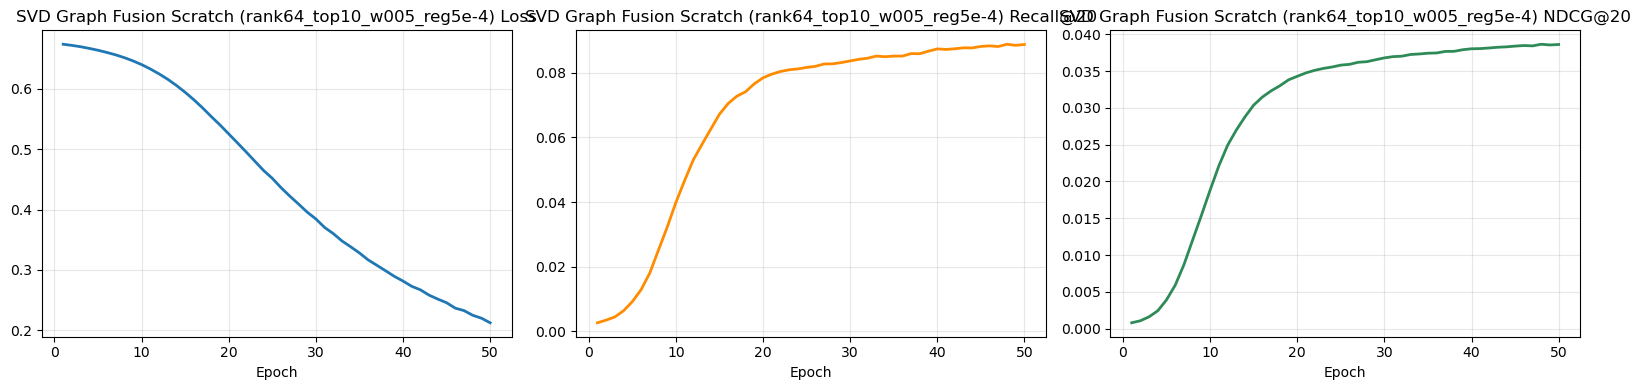

In [18]:
set_global_seed(SEED)
print_section('Training SVD Graph Fusion From Scratch')

def build_weighted_interaction_matrix(train_df, n_users, n_items):
    values = np.clip((train_df['rating'].to_numpy(dtype=np.float32) - 1.0) / 4.0, 0.0, 1.0)
    return sp.csr_matrix((values, (train_df['user_idx'], train_df['item_idx'])), shape=(n_users, n_items))

def compute_svd_factors(interaction_matrix, latent_dim=128):
    latent_dim = min(latent_dim, max(1, min(interaction_matrix.shape) - 1))
    u, singular_values, vt = svds(interaction_matrix, k=latent_dim)
    sort_idx = np.argsort(singular_values)[::-1]
    singular_values, u, vt = singular_values[sort_idx], u[:, sort_idx], vt[sort_idx, :]
    singular_sqrt = np.sqrt(np.clip(singular_values, 1e-8, None)).astype(np.float32)
    return (u * singular_sqrt.reshape(1, -1)).astype(np.float32), (vt.T * singular_sqrt.reshape(1, -1)).astype(np.float32)

def build_svd_global_edges(user_factors, item_factors, observed_items_map, top_k=20, batch_users=512):
    global_user_indices, global_item_indices, global_weights = [], [], []
    item_factor_matrix = item_factors.T.astype(np.float32)
    for start in range(0, user_factors.shape[0], batch_users):
        end = min(start + batch_users, user_factors.shape[0])
        batch_scores = np.matmul(user_factors[start:end], item_factor_matrix)
        for offset, user_idx in enumerate(range(start, end)):
            scores = batch_scores[offset].copy()
            seen_items = observed_items_map.get(int(user_idx), set())
            if seen_items:
                scores[np.fromiter(seen_items, dtype=np.int64)] = -1e9
            k = min(top_k, scores.shape[0])
            top_items = np.argpartition(scores, -k)[-k:]
            top_scores = scores[top_items]
            order = np.argsort(top_scores)[::-1]
            for item_idx, score in zip(top_items[order], top_scores[order]):
                global_user_indices.append(int(user_idx))
                global_item_indices.append(int(item_idx))
                global_weights.append(float(1.0 / (1.0 + np.exp(-score))))
    return np.asarray(global_user_indices), np.asarray(global_item_indices), np.asarray(global_weights, dtype=np.float32)

def build_fused_graph_adj(train_df, n_users, n_items, global_user_indices, global_item_indices, global_weights, global_weight_scale=0.2):
    local_user_indices = train_df['user_idx'].to_numpy(dtype=np.int64)
    local_item_indices = train_df['item_idx'].to_numpy(dtype=np.int64)
    fused_user_indices = np.concatenate([local_user_indices, global_user_indices])
    fused_item_indices = np.concatenate([local_item_indices, global_item_indices])
    fused_weights = np.concatenate([np.ones(len(train_df), dtype=np.float32), global_weight_scale * global_weights])
    row = np.concatenate([fused_user_indices, fused_item_indices + n_users])
    col = np.concatenate([fused_item_indices + n_users, fused_user_indices])
    data = np.concatenate([fused_weights, fused_weights]).astype(np.float32)
    adj = sp.coo_matrix((data, (row, col)), shape=(n_users + n_items, n_users + n_items))
    rowsum = np.asarray(adj.sum(axis=1)).reshape(-1)
    d_inv = np.zeros_like(rowsum, dtype=np.float32)
    np.power(rowsum, -0.5, out=d_inv, where=rowsum > 0)
    norm_adj = sp.diags(d_inv).dot(adj).dot(sp.diags(d_inv)).tocoo()
    return torch.sparse_coo_tensor(torch.LongTensor(np.vstack([norm_adj.row, norm_adj.col])), torch.FloatTensor(norm_adj.data), torch.Size(norm_adj.shape)).coalesce().to(device)

fusion_cfg = MODEL_CONFIGS['svd_graph_fusion']
base_fusion_cfg = {k: v for k, v in fusion_cfg.items() if k != 'variants'}
if fusion_cfg.get('variants'):
    base_fusion_cfg = _merge_dict(base_fusion_cfg, fusion_cfg['variants'][0])
base_fusion_cfg.setdefault('name', 'fixed')
interaction_matrix = build_weighted_interaction_matrix(train_df, n_users, n_items)
svd_factor_cache = {}
svd_edge_cache = {}
svd_adj_cache = {}

def get_svd_fused_adj(cfg):
    latent_dim = int(cfg['latent_dim'])
    top_k_global = int(cfg['top_k_global'])
    global_weight_scale = float(cfg['global_weight_scale'])
    if latent_dim not in svd_factor_cache:
        svd_factor_cache[latent_dim] = compute_svd_factors(interaction_matrix, latent_dim=latent_dim)
    edge_key = (latent_dim, top_k_global)
    if edge_key not in svd_edge_cache:
        user_factors, item_factors = svd_factor_cache[latent_dim]
        svd_edge_cache[edge_key] = build_svd_global_edges(user_factors, item_factors, user_positive_items, top_k=top_k_global)
    adj_key = (latent_dim, top_k_global, global_weight_scale)
    if adj_key not in svd_adj_cache:
        global_u, global_i, global_w = svd_edge_cache[edge_key]
        svd_adj_cache[adj_key] = build_fused_graph_adj(train_df, n_users, n_items, global_u, global_i, global_w, global_weight_scale=global_weight_scale)
    return svd_adj_cache[adj_key]

def run_svd_fusion_trials():
    trials = get_grid_trials('svd_graph_fusion', base_fusion_cfg)
    trial_rows = []
    best_trial = None
    for trial in trials:
        trial_name, cfg = trial['name'], trial['config']
        if trial_name == 'fixed' and cfg.get('name'):
            trial_name = str(cfg['name'])
        print_section(f"SVD Graph Fusion From Scratch Trial: {trial_name}")
        set_global_seed(SEED + trial['index'] - 1)
        fused_adj = get_svd_fused_adj(cfg)
        model = LightGCN(
            n_users,
            n_items,
            embedding_dim=cfg.get('embedding_dim', lightgcn_cfg['embedding_dim']),
            n_layers=cfg.get('n_layers', lightgcn_cfg['n_layers']),
        ).to(device)
        save_path = model_dir / f"{dataset_slug}_svd_graph_fusion_scratch_{_sanitize_trial_name(trial_name)}.pth"
        train_start = time.time()
        history = train_lightgcn_with_val(
            model,
            fused_adj,
            train_df,
            val_df,
            {'lr': cfg['lr'], 'batch_size': cfg['batch_size'], 'reg_weight': cfg['reg_weight']},
            save_path,
        )
        train_time = time.time() - train_start
        model.load_state_dict(torch.load(save_path, map_location=device))
        val_metrics = evaluate_lightgcn(model, fused_adj, val_df, top_k=TOP_K)
        best_epoch, hist_best_ndcg, hist_best_recall = best_values_from_history(history)
        select_ndcg = hist_best_ndcg if history else val_metrics[f'NDCG@{TOP_K}']
        select_recall = hist_best_recall if history else val_metrics[f'Recall@{TOP_K}']
        row = {
            'Model': 'SVD Graph Fusion Scratch',
            'Trial': trial_name,
            f'ValNDCG@{TOP_K}': float(select_ndcg),
            f'ValRecall@{TOP_K}': float(select_recall),
            'BestEpoch': best_epoch,
            'EpochsRan': len(history),
            'TrainingTimeSec': train_time,
            'Checkpoint': str(save_path),
            'Config': cfg,
        }
        trial_rows.append(row)
        if GRID_SEARCH_ENABLED:
            grid_search_rows.append(row)
        if best_trial is None or (select_ndcg, select_recall) > (best_trial['select_ndcg'], best_trial['select_recall']):
            best_trial = {
                'model': model,
                'adj': fused_adj,
                'history': history,
                'train_time': train_time,
                'trial_name': trial_name,
                'config': cfg,
                'save_path': save_path,
                'select_ndcg': float(select_ndcg),
                'select_recall': float(select_recall),
                'trial_rows': trial_rows,
            }
    if trial_rows:
        print('SVD Graph Fusion trial summary:')
        display(pd.DataFrame([{k: v for k, v in row.items() if k != 'Config'} for row in trial_rows]).sort_values([f'ValNDCG@{TOP_K}', f'ValRecall@{TOP_K}'], ascending=[False, False]))
    return best_trial

graph_fusion_best = run_svd_fusion_trials()
best_graph_fusion_model = graph_fusion_best['model']
best_graph_fusion_adj = graph_fusion_best['adj']
best_graph_fusion_name = graph_fusion_best['trial_name']
best_graph_fusion_metrics = evaluate_lightgcn(best_graph_fusion_model, best_graph_fusion_adj, test_df, top_k=TOP_K)

# Replace any previous SVD Graph Fusion row if this cell is rerun in the same kernel.
final_results[:] = [row for row in final_results if not str(row.get('Model', '')).startswith('SVD Graph Fusion')]
training_summary_rows[:] = [row for row in training_summary_rows if not str(row.get('Model', '')).startswith('SVD Graph Fusion')]
record_training_summary(
    'SVD Graph Fusion Scratch',
    graph_fusion_best['history'],
    graph_fusion_best['train_time'],
    loaded_from_checkpoint=False,
    selected_trial=best_graph_fusion_name,
)
append_result('SVD Graph Fusion Scratch', best_graph_fusion_metrics)
display(pd.DataFrame([{'Model': 'SVD Graph Fusion Scratch', 'SelectedTrial': best_graph_fusion_name, **best_graph_fusion_metrics}]))
plot_history(graph_fusion_best['history'], f"SVD Graph Fusion Scratch ({best_graph_fusion_name})")


<a id='section-7-final-comparison'></a>
##### 7. Final Comparison



Final Comparison
Grid search trials:


,Model,Trial,ValNDCG@20,ValRecall@20,BestEpoch,EpochsRan,TrainingTimeSec,Checkpoint
38,GATv2,emb128_l2_h4_lr5e-4_drop0,0.026666,0.058450,12,17,164.011811,c:\Users\ZHIPE\Desktop\Georgia Tech\7643 Deep ...
34,GATv2,emb64_l2_h8_lr1e-3_drop0,0.026658,0.057329,12,17,162.713862,c:\Users\ZHIPE\Desktop\Georgia Tech\7643 Deep ...
35,GATv2,emb64_l2_h4_lr5e-4_drop0,0.026568,0.057467,15,20,170.474100,c:\Users\ZHIPE\Desktop\Georgia Tech\7643 Deep ...
32,GATv2,emb64_l3_h4_lr1e-3_drop0,0.026362,0.057900,8,13,116.438658,c:\Users\ZHIPE\Desktop\Georgia Tech\7643 Deep ...
37,GATv2,emb64_l2_h4_lr1e-3_l2_5e-5,0.025519,0.056666,11,16,135.357105,c:\Users\ZHIPE\Desktop\Georgia Tech\7643 Deep ...
...,...,...,...,...,...,...,...,...
57,SVD Graph Fusion Scratch,rank64_top20_w005,0.034446,0.079302,50,50,620.068973,c:\Users\ZHIPE\Desktop\Georgia Tech\7643 Deep ...
62,SVD Graph Fusion Scratch,rank64_top10_w005_lr1e-4,0.031547,0.073882,50,50,616.754796,c:\Users\ZHIPE\Desktop\Georgia Tech\7643 Deep ...
56,SVD Graph Fusion Scratch,rank64_top10_w020,0.029851,0.068071,15,20,243.322046,c:\Users\ZHIPE\Desktop\Georgia Tech\7643 Deep ...
58,SVD Graph Fusion Scratch,rank64_top20_w010,0.028878,0.065992,15,20,249.093142,c:\Users\ZHIPE\Desktop\Georgia Tech\7643 Deep ...


Effectiveness metrics:


,Model,SelectedTrial,NDCG@20,Recall@20,Precision@20,MRR,num_users
1,LightGCN BPR,emb128_l3_lr1e-3_reg1e-4,0.032297,0.070885,0.004403,0.023860,15093
5,SVD Graph Fusion Scratch,rank64_top10_w005_reg5e-4,0.031042,0.066146,0.004071,0.023172,15093
0,MLP Two Tower BPR,emb128_h256-128_lr1e-3_reg1e-4,0.029908,0.057304,0.003505,0.024601,15093
4,GraphSAGE,emb256_h256_l2_drop02_lr5e-4,0.027423,0.051717,0.003177,0.022817,15093
2,LightGCL,emb128_l2_rank10_tau05_cl01,0.027367,0.050068,0.003097,0.023220,15093
3,GATv2,emb128_l2_h4_lr5e-4_drop0,0.026023,0.047402,0.002958,0.022247,15093


Training efficiency and early stopping:


,Model,SelectedTrial,EpochsRan,BestEpoch,BestValNDCG@20,BestValRecall@20,EarlyStopped,TrainingTimeSec,LoadedFromCheckpoint,Skipped
0,MLP Two Tower BPR,emb128_h256-128_lr1e-3_reg1e-4,12,7,0.029885,0.066226,True,392.279332,False,False
1,LightGCN BPR,emb128_l3_lr1e-3_reg1e-4,40,35,0.045686,0.101039,True,509.107031,False,False
2,LightGCL,emb128_l2_rank10_tau05_cl01,9,4,0.028657,0.062306,True,67.749847,False,False
3,GATv2,emb128_l2_h4_lr5e-4_drop0,17,12,0.026666,0.058450,True,164.011811,False,False
4,GraphSAGE,emb256_h256_l2_drop02_lr5e-4,7,2,0.028063,0.062652,True,75.261208,False,False
5,SVD Graph Fusion Scratch,rank64_top10_w005_reg5e-4,50,48,0.038660,0.088806,False,610.306028,False,False


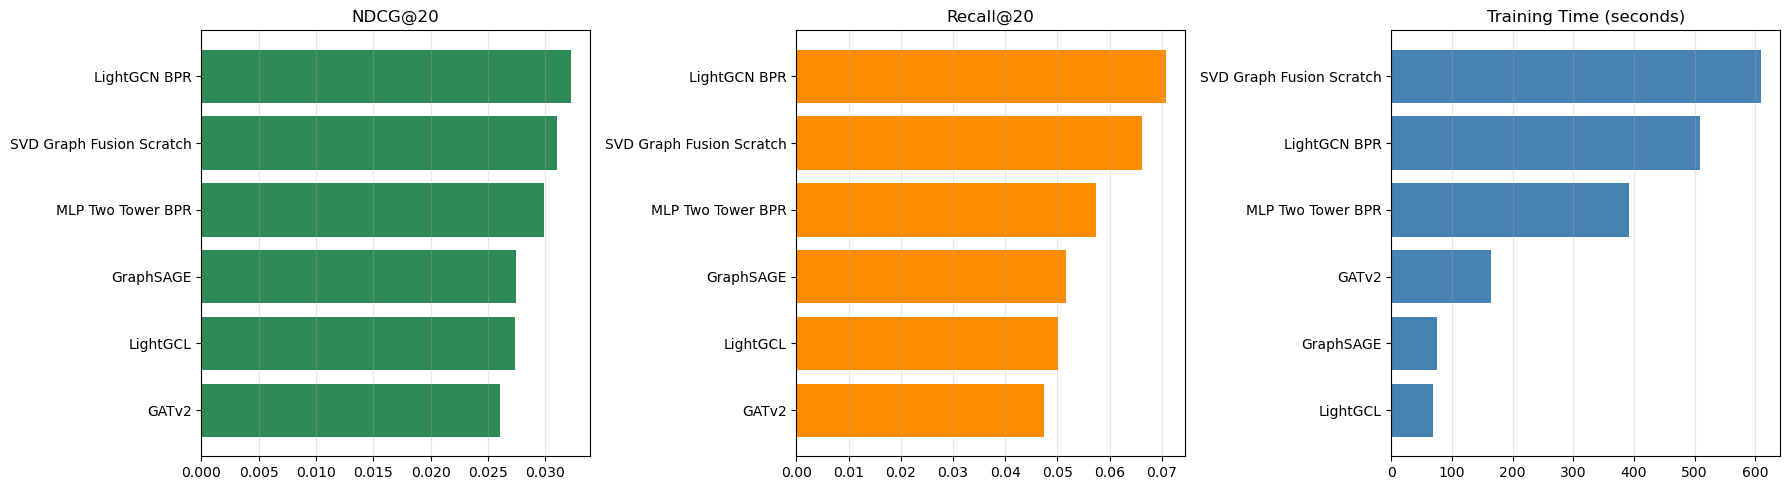

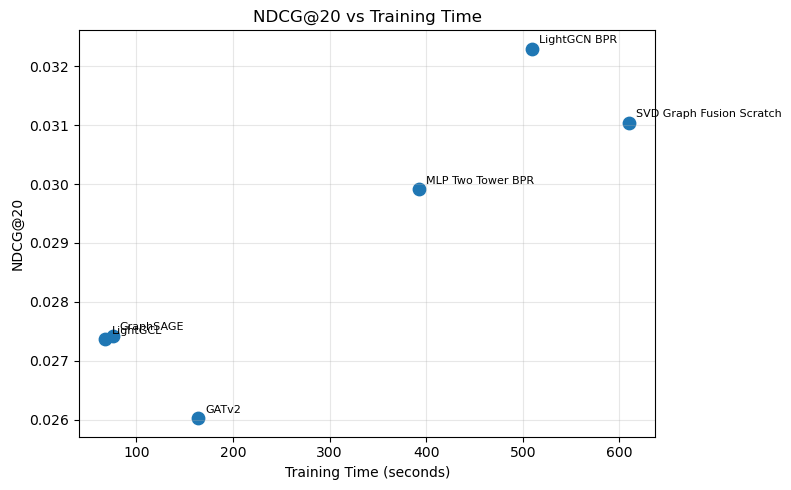

In [21]:
print_section('Final Comparison')

final_comparison_df = pd.DataFrame(final_results)
training_summary_df = pd.DataFrame(training_summary_rows)
comparison_with_runtime_df = final_comparison_df.merge(training_summary_df, on='Model', how='left')

effectiveness_cols = ['Model', 'SelectedTrial', f'NDCG@{TOP_K}', f'Recall@{TOP_K}', f'Precision@{TOP_K}', 'MRR', 'num_users']
runtime_cols = [
    'Model', 'SelectedTrial', 'EpochsRan', 'BestEpoch', f'BestValNDCG@{TOP_K}', f'BestValRecall@{TOP_K}',
    'EarlyStopped', 'TrainingTimeSec', 'LoadedFromCheckpoint', 'Skipped'
]

if grid_search_rows:
    print('Grid search trials:')
    grid_search_df = pd.DataFrame([{k: v for k, v in row.items() if k != 'Config'} for row in grid_search_rows])
    display(grid_search_df.sort_values(['Model', f'ValNDCG@{TOP_K}', f'ValRecall@{TOP_K}'], ascending=[True, False, False]))

print('Effectiveness metrics:')
display(comparison_with_runtime_df[[col for col in effectiveness_cols if col in comparison_with_runtime_df.columns]].sort_values(f'NDCG@{TOP_K}', ascending=False))
print('Training efficiency and early stopping:')
display(comparison_with_runtime_df[[col for col in runtime_cols if col in comparison_with_runtime_df.columns]])

fig, axes = plt.subplots(1, 3, figsize=(18, 5))
plot_df = comparison_with_runtime_df.sort_values(f'NDCG@{TOP_K}', ascending=True)
axes[0].barh(plot_df['Model'], plot_df[f'NDCG@{TOP_K}'], color='seagreen')
axes[0].set_title(f'NDCG@{TOP_K}')
axes[0].grid(axis='x', alpha=0.3)

plot_df = comparison_with_runtime_df.sort_values(f'Recall@{TOP_K}', ascending=True)
axes[1].barh(plot_df['Model'], plot_df[f'Recall@{TOP_K}'], color='darkorange')
axes[1].set_title(f'Recall@{TOP_K}')
axes[1].grid(axis='x', alpha=0.3)

plot_df = comparison_with_runtime_df.sort_values('TrainingTimeSec', ascending=True)
axes[2].barh(plot_df['Model'], plot_df['TrainingTimeSec'], color='steelblue')
axes[2].set_title('Training Time (seconds)')
axes[2].grid(axis='x', alpha=0.3)
plt.tight_layout()
plt.show()

fig, ax = plt.subplots(figsize=(8, 5))
ax.scatter(comparison_with_runtime_df['TrainingTimeSec'], comparison_with_runtime_df[f'NDCG@{TOP_K}'], s=80)
for _, row in comparison_with_runtime_df.iterrows():
    ax.annotate(row['Model'], (row['TrainingTimeSec'], row[f'NDCG@{TOP_K}']), fontsize=8, xytext=(5, 4), textcoords='offset points')
ax.set_xlabel('Training Time (seconds)')
ax.set_ylabel(f'NDCG@{TOP_K}')
ax.set_title(f'NDCG@{TOP_K} vs Training Time')
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()


<a id='section-8-model-behavior-analysis'></a>
##### 8. Model Behavior Analysis

This report-oriented section explains model behavior beyond aggregate NDCG@20 and Recall@20. It focuses on hit rate, catalog coverage, item popularity bias, recommendation quality, and the relationship between popularity and ranking performance.



Model Behavior Analysis
Available models for behavior analysis: ['MLP Two Tower BPR', 'LightGCN BPR', 'LightGCL', 'GATv2', 'GraphSAGE', 'SVD Graph Fusion Scratch']


,Model,user_idx,rank,item_idx,score,is_hit,item_popularity,item_avg_rating,num_relevant_items
0,MLP Two Tower BPR,0,1,5719,4.380412,0,238,4.794118,1
1,MLP Two Tower BPR,0,2,649,4.295299,0,261,4.708812,1
2,MLP Two Tower BPR,0,3,5720,3.914163,0,183,4.759563,1
3,MLP Two Tower BPR,0,4,1188,3.726848,0,191,4.743455,1
4,MLP Two Tower BPR,0,5,345,3.715185,0,150,4.413333,1


,Model,NDCG@20,Recall@20,HitRateAt20,AvgUserRecallAt20,CatalogCoverage,AvgRecommendedPopularity,AvgRecommendedRating,AvgFirstHitRank
3,LightGCN BPR,0.032297,0.070885,0.085205,0.070885,0.760243,59.708004,4.653038,8.050544
5,SVD Graph Fusion Scratch,0.031042,0.066146,0.078579,0.066146,0.401291,90.221083,4.677125,7.606239
4,MLP Two Tower BPR,0.029908,0.057304,0.068509,0.057304,0.003725,126.108885,4.679299,7.625725
1,GraphSAGE,0.027423,0.051717,0.062214,0.051717,0.003849,128.242559,4.671491,7.484558
2,LightGCL,0.027367,0.050068,0.060425,0.050068,0.051031,125.902504,4.673274,7.059211
0,GATv2,0.026023,0.047402,0.057908,0.047402,0.013161,101.375376,4.650404,7.289474


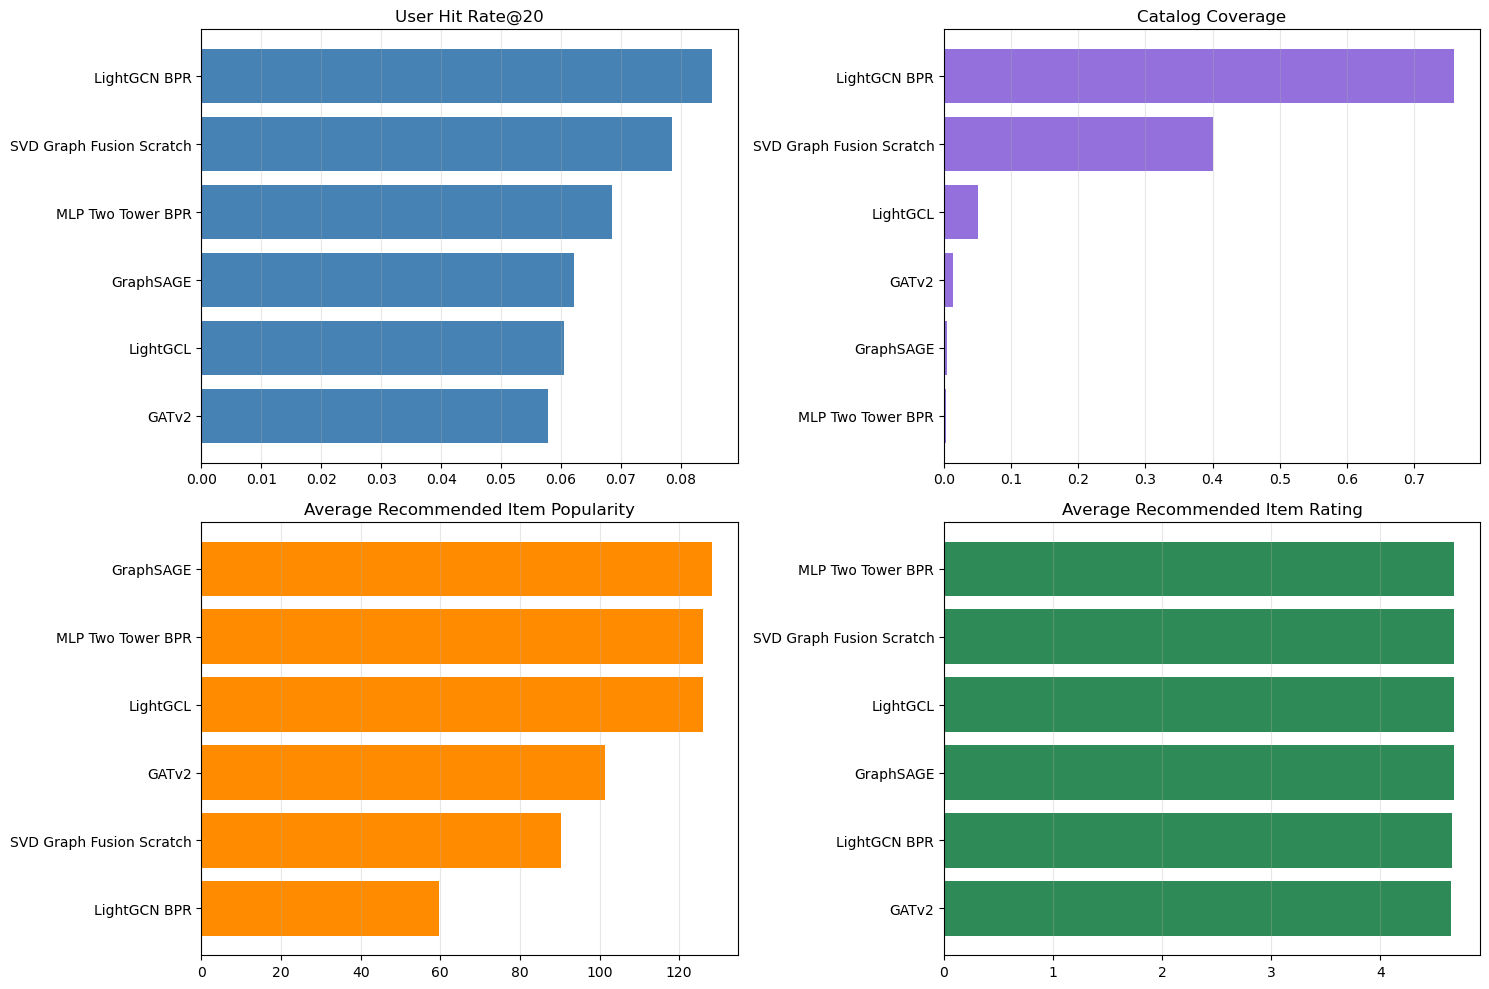

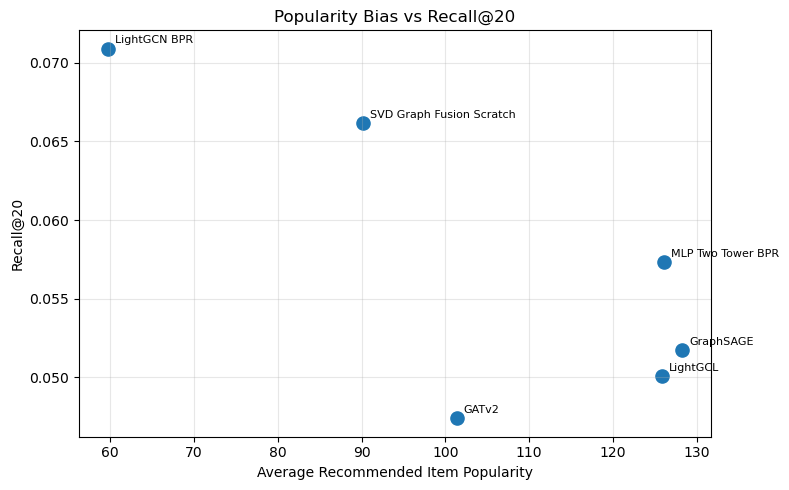

,Model,user_idx,rank,item_idx,score,item_popularity,item_avg_rating
914460,GATv2,444,1,5719,12.646276,238,4.794118
915060,GATv2,474,1,5719,15.861982,238,4.794118
915520,GATv2,497,1,5719,13.874410,238,4.794118
915820,GATv2,512,1,5719,7.260947,238,4.794118
917020,GATv2,572,1,5719,9.232462,238,4.794118
1213540,GraphSAGE,305,1,5719,6.776955,238,4.794118
1216320,GraphSAGE,444,1,5719,8.304524,238,4.794118
1216920,GraphSAGE,474,1,5719,6.619683,238,4.794118
1217380,GraphSAGE,497,1,5719,6.909641,238,4.794118
1217680,GraphSAGE,512,1,5719,10.164704,238,4.794118


In [22]:
print_section('Model Behavior Analysis')

ANALYSIS_MAX_USERS = None if n_users <= 50000 else 5000
ANALYSIS_RANDOM_SEED = SEED

def _sample_analysis_users(eval_df, max_users=None):
    relevant_by_user = _group_relevant_items(eval_df, RELEVANCE_THRESHOLD)
    users = np.array(sorted(relevant_by_user.keys()), dtype=np.int64)
    if max_users is not None and len(users) > max_users:
        rng = np.random.default_rng(ANALYSIS_RANDOM_SEED)
        users = np.sort(rng.choice(users, size=max_users, replace=False))
    return users, relevant_by_user

def _build_behavior_score_functions():
    score_functions = {}
    all_items_tensor = torch.arange(n_items, device=device)

    if 'two_tower_bpr_model' in globals():
        two_tower_bpr_model.eval()
        score_functions['MLP Two Tower BPR'] = lambda user_idx: _score_two_tower_all_items(two_tower_bpr_model, user_idx, all_items_tensor)

    if 'lightgcn_bpr_model' in globals():
        lightgcn_bpr_model.eval()
        with torch.no_grad():
            lgcn_user_emb, lgcn_item_emb = lightgcn_bpr_model.computer(norm_adj_tensor)
        def score_lightgcn(user_idx):
            raw_scores = (lgcn_user_emb[user_idx].unsqueeze(0) * lgcn_item_emb).sum(dim=1)
            users_batch = torch.full((n_items,), int(user_idx), dtype=torch.long, device=device)
            return lightgcn_bpr_model._apply_rating_head(raw_scores, users_batch, all_items_tensor, apply_range=True)
        score_functions['LightGCN BPR'] = score_lightgcn

    if 'lightgcl_model' in globals():
        lightgcl_model.eval()
        with torch.no_grad():
            lightgcl_user_emb, lightgcl_item_emb, *_ = lightgcl_model.propagate(norm_adj_tensor)
        score_functions['LightGCL'] = lambda user_idx: lightgcl_user_emb[user_idx] @ lightgcl_item_emb.t()

    if 'gat_model' in globals() and globals().get('gat_metrics') is not None and 'edge_index' in globals():
        gat_model.eval()
        with torch.no_grad():
            gat_user_emb, gat_item_emb = gat_model.propagate(edge_index)
        score_functions['GATv2'] = lambda user_idx: gat_user_emb[user_idx] @ gat_item_emb.t()

    if 'graphsage_model' in globals():
        graphsage_model.eval()
        with torch.no_grad():
            sage_user_emb, sage_item_emb = graphsage_model.get_all_embeddings(norm_adj_tensor)
        def score_graphsage(user_idx):
            user_tensor = torch.LongTensor([user_idx]).to(device)
            scores = torch.matmul(sage_item_emb, sage_user_emb[user_idx])
            scores = scores + graphsage_model.item_bias(all_items_tensor).squeeze(-1)
            scores = scores + graphsage_model.user_bias(user_tensor).squeeze(-1)
            scores = scores + graphsage_model.global_bias
            return scores
        score_functions['GraphSAGE'] = score_graphsage

    if 'best_graph_fusion_model' in globals() and 'best_graph_fusion_adj' in globals():
        best_graph_fusion_model.eval()
        with torch.no_grad():
            fusion_user_emb, fusion_item_emb = best_graph_fusion_model.computer(best_graph_fusion_adj)
        def score_fusion(user_idx):
            raw_scores = (fusion_user_emb[user_idx].unsqueeze(0) * fusion_item_emb).sum(dim=1)
            users_batch = torch.full((n_items,), int(user_idx), dtype=torch.long, device=device)
            return best_graph_fusion_model._apply_rating_head(raw_scores, users_batch, all_items_tensor, apply_range=True)
        score_functions['SVD Graph Fusion Scratch'] = score_fusion

    return score_functions

def collect_topk_recommendations(score_functions, eval_df, top_k=TOP_K, max_users=ANALYSIS_MAX_USERS):
    users, relevant_by_user = _sample_analysis_users(eval_df, max_users=max_users)
    item_popularity = train_df.groupby('item_idx').size().to_dict()
    item_avg_rating = train_df.groupby('item_idx')['rating'].mean().to_dict()
    global_avg_rating = float(train_df['rating'].mean())
    rows = []

    for model_name, score_fn in score_functions.items():
        print(f'Collecting Top-{top_k} recommendations for {model_name} on {len(users):,} users...')
        for user_idx in users:
            relevant_items = relevant_by_user.get(int(user_idx), set())
            if not relevant_items:
                continue
            scores = score_fn(int(user_idx)).detach().clone()
            seen_items = list(user_positive_items.get(int(user_idx), set()))
            if seen_items:
                scores[seen_items] = -1e9
            top_scores, top_items = torch.topk(scores, k=min(top_k, scores.numel()))
            for rank, (item_idx, score_value) in enumerate(zip(top_items.cpu().numpy(), top_scores.cpu().numpy()), start=1):
                item_idx = int(item_idx)
                rows.append({
                    'Model': model_name,
                    'user_idx': int(user_idx),
                    'rank': rank,
                    'item_idx': item_idx,
                    'score': float(score_value),
                    'is_hit': int(item_idx in relevant_items),
                    'item_popularity': int(item_popularity.get(item_idx, 0)),
                    'item_avg_rating': float(item_avg_rating.get(item_idx, global_avg_rating)),
                    'num_relevant_items': len(relevant_items),
                })
    return pd.DataFrame(rows)

behavior_score_functions = _build_behavior_score_functions()
print(f'Available models for behavior analysis: {list(behavior_score_functions.keys())}')
topk_recommendations_df = collect_topk_recommendations(behavior_score_functions, test_df, top_k=TOP_K, max_users=ANALYSIS_MAX_USERS)
display(topk_recommendations_df.head())

if topk_recommendations_df.empty:
    print('No recommendations collected. Run the model sections first, then rerun this section.')
else:
    per_user_behavior_df = topk_recommendations_df.groupby(['Model', 'user_idx'], as_index=False).agg(
        hits=('is_hit', 'sum'),
        num_relevant_items=('num_relevant_items', 'first'),
    )
    first_hit_rank_df = (
        topk_recommendations_df[topk_recommendations_df['is_hit'] == 1]
        .groupby(['Model', 'user_idx'], as_index=False)['rank']
        .min()
        .rename(columns={'rank': 'AvgFirstHitRank'})
    )
    per_user_behavior_df = per_user_behavior_df.merge(first_hit_rank_df, on=['Model', 'user_idx'], how='left')
    per_user_behavior_df[f'Recall@{TOP_K}'] = per_user_behavior_df['hits'] / per_user_behavior_df['num_relevant_items']

    behavior_summary_df = topk_recommendations_df.groupby('Model').agg(
        AvgRecommendedPopularity=('item_popularity', 'mean'),
        MedianRecommendedPopularity=('item_popularity', 'median'),
        AvgRecommendedRating=('item_avg_rating', 'mean'),
        CatalogCoverage=('item_idx', lambda x: x.nunique() / n_items),
    ).reset_index()
    user_hit_summary = per_user_behavior_df.groupby('Model').agg(
        HitRateAt20=('hits', lambda x: float((x > 0).mean())),
        AvgUserRecallAt20=(f'Recall@{TOP_K}', 'mean'),
        AvgFirstHitRank=('AvgFirstHitRank', 'mean'),
    ).reset_index()
    behavior_summary_df = behavior_summary_df.merge(user_hit_summary, on='Model', how='left')

    behavior_report_df = behavior_summary_df
    if 'final_comparison_df' in globals():
        behavior_report_df = behavior_report_df.merge(
            final_comparison_df[['Model', f'NDCG@{TOP_K}', f'Recall@{TOP_K}']],
            on='Model',
            how='left',
        )

    behavior_cols = [
        'Model', f'NDCG@{TOP_K}', f'Recall@{TOP_K}', 'HitRateAt20', 'AvgUserRecallAt20',
        'CatalogCoverage', 'AvgRecommendedPopularity', 'AvgRecommendedRating', 'AvgFirstHitRank'
    ]
    behavior_sort_col = f'Recall@{TOP_K}' if f'Recall@{TOP_K}' in behavior_report_df.columns else 'AvgUserRecallAt20'
    display(behavior_report_df[[col for col in behavior_cols if col in behavior_report_df.columns]].sort_values(behavior_sort_col, ascending=False))

    fig, axes = plt.subplots(2, 2, figsize=(15, 10))
    plot_df = behavior_report_df.sort_values('HitRateAt20', ascending=True)
    axes[0, 0].barh(plot_df['Model'], plot_df['HitRateAt20'], color='steelblue')
    axes[0, 0].set_title(f'User Hit Rate@{TOP_K}')
    axes[0, 0].grid(axis='x', alpha=0.3)

    plot_df = behavior_report_df.sort_values('CatalogCoverage', ascending=True)
    axes[0, 1].barh(plot_df['Model'], plot_df['CatalogCoverage'], color='mediumpurple')
    axes[0, 1].set_title('Catalog Coverage')
    axes[0, 1].grid(axis='x', alpha=0.3)

    plot_df = behavior_report_df.sort_values('AvgRecommendedPopularity', ascending=True)
    axes[1, 0].barh(plot_df['Model'], plot_df['AvgRecommendedPopularity'], color='darkorange')
    axes[1, 0].set_title('Average Recommended Item Popularity')
    axes[1, 0].grid(axis='x', alpha=0.3)

    plot_df = behavior_report_df.sort_values('AvgRecommendedRating', ascending=True)
    axes[1, 1].barh(plot_df['Model'], plot_df['AvgRecommendedRating'], color='seagreen')
    axes[1, 1].set_title('Average Recommended Item Rating')
    axes[1, 1].grid(axis='x', alpha=0.3)
    plt.tight_layout()
    plt.show()

    fig, ax = plt.subplots(figsize=(8, 5))
    scatter_y_col = f'Recall@{TOP_K}' if f'Recall@{TOP_K}' in behavior_report_df.columns else 'AvgUserRecallAt20'
    ax.scatter(behavior_report_df['AvgRecommendedPopularity'], behavior_report_df[scatter_y_col], s=90)
    for _, row in behavior_report_df.iterrows():
        ax.annotate(row['Model'], (row['AvgRecommendedPopularity'], row[scatter_y_col]), fontsize=8, xytext=(5, 4), textcoords='offset points')
    ax.set_xlabel('Average Recommended Item Popularity')
    ax.set_ylabel(scatter_y_col)
    ax.set_title(f'Popularity Bias vs {scatter_y_col}')
    ax.grid(True, alpha=0.3)
    plt.tight_layout()
    plt.show()

    example_hits_df = topk_recommendations_df[topk_recommendations_df['is_hit'] == 1].sort_values(['Model', 'rank']).groupby('Model').head(5)
    display(example_hits_df[['Model', 'user_idx', 'rank', 'item_idx', 'score', 'item_popularity', 'item_avg_rating']])
